# ARI(p, d) モデルでガウス係数ベクトルを学習させたときの最適パラメータ

- 係数間相互作用は無視する。
- SARIMAX モデルを使う。LikelihoodとAICのHeatmapを書く。→ p+d=3が最善を証明する
- `simple_differencing = True` とする。
- `ignore_stationality/invertibility = True` とする。

In [1]:
import platform                  # Python 3.9.16
import sys

import numpy             as np   # Numpy 1.23.2
import pandas            as pd   # Pandas 2.0.3
import matplotlib.pyplot as plt
%matplotlib inline
# print(plt.rcParams.keys())
plt.rcParams.update({
    'font.size'     : 16,
    'axes.grid'     : True,
    'grid.linestyle': '--',
    'lines.linewidth': 2,
})
from matplotlib.colors import LogNorm
import seaborn as sns

from pathlib import Path
savedir = "../reports/figures/1214_SARIMAX(p,d,0)_heatmap/"
Path(savedir).mkdir(parents=True, exist_ok=True)

import statsmodels.api  as sm    # Statsmodels 0.14.0

print(f"Python Platform: {platform.platform()}")
print(f"Python {sys.version}")
print(f"Pandas {pd.__version__}")
print(f"Numpy {np.__version__}")
print()
print(f"Statsmodels {sm.__version__}")
print()

Python Platform: macOS-13.4-arm64-arm-64bit
Python 3.9.16 | packaged by conda-forge | (main, Feb  1 2023, 21:38:11) 
[Clang 14.0.6 ]
Pandas 2.0.3
Numpy 1.23.2

Statsmodels 0.14.0



In [2]:
coef_raw = pd.read_csv("../data/processed/coef.csv")

# make column of name = "letter(n, m)"
coef = coef_raw.iloc[:195, :]

coef["coef"] = coef["letter"] + "(" + coef["n"].astype(str) + ", " + coef["m"].astype(str) + ")"

coef_dfT = coef.loc[:, "2004.75":"2019.50"]

coef_dfT.index = coef["coef"]

coef_df = coef_dfT.T

# インデックスの範囲を設定（2004年から2019年まで3ヶ月ごと）
# start_date, end_date = '2004-10-01', '2019-07-01'
# coef_df.index = pd.date_range(start=start_date, end=end_date, freq="QS")

coef_df.index.name = "YEAR"
coef_df.index = coef_df.index.astype(float)

display(coef_df)

/var/folders/m6/3_6_32s90qdf_nhdhwt9413w0000gn/T/ipykernel_91017/631961878.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef["coef"] = coef["letter"] + "(" + coef["n"].astype(str) + ", " + coef["m"].astype(str) + ")"


coef,"g(1, 0)","g(1, 1)","h(1, 1)","g(2, 0)","g(2, 1)","h(2, 1)","g(2, 2)","h(2, 2)","g(3, 0)","g(3, 1)",...,"g(13, 9)","h(13, 9)","g(13, 10)","h(13, 10)","g(13, 11)","h(13, 11)","g(13, 12)","h(13, 12)","g(13, 13)","h(13, 13)"
YEAR,,,,,,,,,,,,,,,,,,,,,
2004.75,-29555.37,-1672.562,5083.327,-2333.885,3048.621,-2588.899,1657.819,-512.5044,1336.003,-2304.827,...,0.347673,0.527706,-0.051912,0.394486,0.407936,-0.237999,-0.119698,-0.569100,-0.187342,-0.839604
2005.00,-29552.40,-1669.005,5077.600,-2336.995,3047.363,-2594.429,1657.606,-515.2604,1336.067,-2305.820,...,0.350986,0.526671,-0.048617,0.396378,0.411378,-0.238317,-0.127115,-0.565939,-0.189713,-0.841823
2005.25,-29549.40,-1665.296,5071.916,-2340.096,3046.127,-2599.968,1657.490,-517.9986,1336.115,-2306.836,...,0.354162,0.525783,-0.045149,0.398017,0.415089,-0.238496,-0.134140,-0.562783,-0.191866,-0.843815
2005.50,-29546.44,-1661.573,5066.217,-2343.176,3044.880,-2605.541,1657.489,-520.7021,1336.181,-2307.883,...,0.357142,0.525001,-0.041508,0.399368,0.418995,-0.238459,-0.140693,-0.559620,-0.193851,-0.845491
2005.75,-29543.48,-1657.719,5060.500,-2346.239,3043.621,-2611.204,1657.564,-523.3253,1336.234,-2308.959,...,0.359874,0.524350,-0.037673,0.400387,0.423086,-0.238180,-0.146799,-0.556445,-0.195654,-0.846816
2006.00,-29540.53,-1653.784,5054.744,-2349.312,3042.369,-2616.841,1657.794,-525.9493,1336.271,-2310.054,...,0.362393,0.523775,-0.033629,0.401063,0.427350,-0.237651,-0.152446,-0.553222,-0.197276,-0.847748
2006.25,-29537.54,-1649.742,5048.962,-2352.381,3041.139,-2622.481,1658.172,-528.5783,1336.298,-2311.141,...,0.364692,0.523238,-0.029394,0.401392,0.431696,-0.236912,-0.157563,-0.549925,-0.198752,-0.848219
2006.50,-29534.57,-1645.501,5043.058,-2355.428,3039.898,-2628.080,1658.689,-531.2026,1336.352,-2312.237,...,0.366734,0.522800,-0.025093,0.401460,0.436105,-0.235959,-0.162110,-0.546468,-0.200158,-0.848209
2006.75,-29531.56,-1641.101,5037.018,-2358.420,3038.676,-2633.686,1659.322,-533.8682,1336.409,-2313.325,...,0.368490,0.522494,-0.020736,0.401269,0.440523,-0.234783,-0.166143,-0.542680,-0.201528,-0.847735


## create train / test data


In [3]:
transformer_df = pd.DataFrame(index=["min_val", "max_val", "scale"], columns=coef_df.columns)
scaled_df = pd.DataFrame(index=coef_df.index, columns=coef_df.columns)

for col in coef_df.columns:
    min_val, max_val = coef_df[col].min(), coef_df[col].max()
    scale = max_val - min_val

    transformer_df.loc["min_val", col] = min_val
    transformer_df.loc["max_val", col] = max_val
    transformer_df.loc["scale", col] = scale

    scaled_df[col] = (coef_df[col] - min_val) / scale

scaled_df = coef_df.copy()

train_df = scaled_df.loc[2004.75:2014.50, :]
test_df  = scaled_df.loc[2014.75:2019.50, :]

train_size, test_size = len(train_df), len(test_df)

display(train_df)
display(test_df)

coef,"g(1, 0)","g(1, 1)","h(1, 1)","g(2, 0)","g(2, 1)","h(2, 1)","g(2, 2)","h(2, 2)","g(3, 0)","g(3, 1)",...,"g(13, 9)","h(13, 9)","g(13, 10)","h(13, 10)","g(13, 11)","h(13, 11)","g(13, 12)","h(13, 12)","g(13, 13)","h(13, 13)"
YEAR,,,,,,,,,,,,,,,,,,,,,
2004.75,-29555.37,-1672.562,5083.327,-2333.885,3048.621,-2588.899,1657.819,-512.5044,1336.003,-2304.827,...,0.347673,0.527706,-0.051912,0.394486,0.407936,-0.237999,-0.119698,-0.569100,-0.187342,-0.839604
2005.00,-29552.40,-1669.005,5077.600,-2336.995,3047.363,-2594.429,1657.606,-515.2604,1336.067,-2305.820,...,0.350986,0.526671,-0.048617,0.396378,0.411378,-0.238317,-0.127115,-0.565939,-0.189713,-0.841823
2005.25,-29549.40,-1665.296,5071.916,-2340.096,3046.127,-2599.968,1657.490,-517.9986,1336.115,-2306.836,...,0.354162,0.525783,-0.045149,0.398017,0.415089,-0.238496,-0.134140,-0.562783,-0.191866,-0.843815
2005.50,-29546.44,-1661.573,5066.217,-2343.176,3044.880,-2605.541,1657.489,-520.7021,1336.181,-2307.883,...,0.357142,0.525001,-0.041508,0.399368,0.418995,-0.238459,-0.140693,-0.559620,-0.193851,-0.845491
2005.75,-29543.48,-1657.719,5060.500,-2346.239,3043.621,-2611.204,1657.564,-523.3253,1336.234,-2308.959,...,0.359874,0.524350,-0.037673,0.400387,0.423086,-0.238180,-0.146799,-0.556445,-0.195654,-0.846816
2006.00,-29540.53,-1653.784,5054.744,-2349.312,3042.369,-2616.841,1657.794,-525.9493,1336.271,-2310.054,...,0.362393,0.523775,-0.033629,0.401063,0.427350,-0.237651,-0.152446,-0.553222,-0.197276,-0.847748
2006.25,-29537.54,-1649.742,5048.962,-2352.381,3041.139,-2622.481,1658.172,-528.5783,1336.298,-2311.141,...,0.364692,0.523238,-0.029394,0.401392,0.431696,-0.236912,-0.157563,-0.549925,-0.198752,-0.848219
2006.50,-29534.57,-1645.501,5043.058,-2355.428,3039.898,-2628.080,1658.689,-531.2026,1336.352,-2312.237,...,0.366734,0.522800,-0.025093,0.401460,0.436105,-0.235959,-0.162110,-0.546468,-0.200158,-0.848209
2006.75,-29531.56,-1641.101,5037.018,-2358.420,3038.676,-2633.686,1659.322,-533.8682,1336.409,-2313.325,...,0.368490,0.522494,-0.020736,0.401269,0.440523,-0.234783,-0.166143,-0.542680,-0.201528,-0.847735


coef,"g(1, 0)","g(1, 1)","h(1, 1)","g(2, 0)","g(2, 1)","h(2, 1)","g(2, 2)","h(2, 2)","g(3, 0)","g(3, 1)",...,"g(13, 9)","h(13, 9)","g(13, 10)","h(13, 10)","g(13, 11)","h(13, 11)","g(13, 12)","h(13, 12)","g(13, 13)","h(13, 13)"
YEAR,,,,,,,,,,,,,,,,,,,,,
2014.75,-29441.95,-1505.608,4803.055,-2443.696,3013.440,-2838.664,1675.706,-638.5029,1349.459,-2351.104,...,0.442585,0.559654,0.060393,0.399106,0.537636,-0.269423,-0.138836,-0.333975,-0.214342,-0.714157
2015.00,-29439.34,-1501.502,4796.114,-2446.164,3012.359,-2845.424,1676.119,-642.2274,1350.258,-2352.410,...,0.447066,0.560625,0.056474,0.401958,0.541337,-0.272562,-0.139276,-0.329428,-0.216694,-0.709809
2015.25,-29436.90,-1497.488,4789.171,-2448.652,3011.267,-2852.262,1676.494,-646.0100,1351.044,-2353.720,...,0.451357,0.561473,0.052282,0.404628,0.545381,-0.275661,-0.140064,-0.325145,-0.219275,-0.705435
2015.50,-29434.64,-1493.663,4782.083,-2451.188,3010.094,-2859.170,1676.886,-649.8412,1351.843,-2355.015,...,0.455408,0.562214,0.047874,0.407114,0.549741,-0.278675,-0.141211,-0.321101,-0.222063,-0.701055
2015.75,-29432.58,-1490.133,4774.777,-2453.761,3008.807,-2866.120,1677.275,-653.7110,1352.605,-2356.289,...,0.459206,0.562867,0.043313,0.409418,0.554373,-0.281616,-0.142715,-0.317287,-0.225044,-0.696658
2016.00,-29430.60,-1486.786,4767.293,-2456.350,3007.462,-2873.026,1677.680,-657.6394,1353.350,-2357.600,...,0.462700,0.563461,0.038639,0.411535,0.559219,-0.284436,-0.144619,-0.313699,-0.228199,-0.692234
2016.25,-29428.66,-1483.590,4759.751,-2458.926,3006.111,-2880.072,1678.106,-661.5989,1354.024,-2358.944,...,0.465885,0.563988,0.033887,0.413486,0.564220,-0.287091,-0.146901,-0.310329,-0.231501,-0.687817
2016.50,-29426.80,-1480.675,4752.056,-2461.528,3004.733,-2887.194,1678.536,-665.5403,1354.694,-2360.295,...,0.468796,0.564401,0.029128,0.415325,0.569333,-0.289575,-0.149496,-0.307130,-0.234922,-0.683458
2016.75,-29424.98,-1477.968,4744.381,-2464.128,3003.312,-2894.444,1678.908,-669.5010,1355.355,-2361.643,...,0.471421,0.564724,0.024407,0.417039,0.574515,-0.291884,-0.152418,-0.304084,-0.238434,-0.679199


### 時間差分データの作成

In [4]:
display(coef_df.loc[2005.00, "g(1, 0)"] - coef_df.loc[2004.75, "g(1, 0)"])
display(coef_df.diff(1, "index").dropna())

2.969999999997526

coef,"g(1, 0)","g(1, 1)","h(1, 1)","g(2, 0)","g(2, 1)","h(2, 1)","g(2, 2)","h(2, 2)","g(3, 0)","g(3, 1)",...,"g(13, 9)","h(13, 9)","g(13, 10)","h(13, 10)","g(13, 11)","h(13, 11)","g(13, 12)","h(13, 12)","g(13, 13)","h(13, 13)"
YEAR,,,,,,,,,,,,,,,,,,,,,
2005.00,2.97,3.557,-5.727,-3.110,-1.258,-5.530,-0.213,-2.7560,0.064,-0.993,...,0.003312,-0.001035,0.003295,0.001892,0.003442,-0.000318,-0.007416,0.003161,-0.002372,-0.002219
2005.25,3.00,3.709,-5.684,-3.101,-1.236,-5.539,-0.116,-2.7382,0.048,-1.016,...,0.003176,-0.000888,0.003468,0.001639,0.003711,-0.000179,-0.007026,0.003156,-0.002153,-0.001992
2005.50,2.96,3.723,-5.699,-3.080,-1.247,-5.573,-0.001,-2.7035,0.066,-1.047,...,0.002980,-0.000782,0.003641,0.001351,0.003906,0.000037,-0.006553,0.003163,-0.001986,-0.001675
2005.75,2.96,3.854,-5.717,-3.063,-1.259,-5.663,0.075,-2.6232,0.053,-1.076,...,0.002732,-0.000651,0.003834,0.001020,0.004091,0.000278,-0.006106,0.003174,-0.001803,-0.001325
2006.00,2.95,3.935,-5.756,-3.073,-1.252,-5.637,0.230,-2.6240,0.037,-1.095,...,0.002519,-0.000575,0.004045,0.000676,0.004264,0.000529,-0.005647,0.003224,-0.001622,-0.000932
2006.25,2.99,4.042,-5.782,-3.069,-1.230,-5.640,0.378,-2.6290,0.027,-1.087,...,0.002300,-0.000537,0.004235,0.000329,0.004346,0.000739,-0.005117,0.003297,-0.001476,-0.000471
2006.50,2.97,4.241,-5.904,-3.047,-1.241,-5.599,0.517,-2.6243,0.054,-1.096,...,0.002042,-0.000438,0.004301,0.000068,0.004408,0.000953,-0.004547,0.003457,-0.001405,0.000010
2006.75,3.01,4.400,-6.040,-2.992,-1.222,-5.606,0.633,-2.6656,0.057,-1.088,...,0.001756,-0.000306,0.004357,-0.000191,0.004419,0.001175,-0.004033,0.003787,-0.001370,0.000474
2007.00,3.02,4.377,-6.228,-2.988,-1.155,-5.523,0.757,-2.7626,0.077,-1.082,...,0.001527,-0.000185,0.004409,-0.000445,0.004393,0.001391,-0.003522,0.004175,-0.001372,0.000927


In [5]:
diff0 = coef_df
diff1 = diff0.diff(1, "index").dropna()
diff2 = diff1.diff(1, "index").dropna()
diff3 = diff2.diff(1, "index").dropna()
diff4 = diff3.diff(1, "index").dropna()

diff = [diff0, diff1, diff2, diff3, diff4]

display(diff2)

coef,"g(1, 0)","g(1, 1)","h(1, 1)","g(2, 0)","g(2, 1)","h(2, 1)","g(2, 2)","h(2, 2)","g(3, 0)","g(3, 1)",...,"g(13, 9)","h(13, 9)","g(13, 10)","h(13, 10)","g(13, 11)","h(13, 11)","g(13, 12)","h(13, 12)","g(13, 13)","h(13, 13)"
YEAR,,,,,,,,,,,,,,,,,,,,,
2005.25,3.000000e-02,0.152,0.043,0.009,0.022,-0.009,0.097,0.0178,-0.016,-2.300000e-02,...,-0.000136,1.472000e-04,0.000173,-0.000252,0.000269,0.000139,0.000391,-0.000005,0.000219,0.000227
2005.50,-4.000000e-02,0.014,-0.015,0.021,-0.011,-0.034,0.115,0.0347,0.018,-3.100000e-02,...,-0.000196,1.066000e-04,0.000173,-0.000288,0.000196,0.000216,0.000473,0.000007,0.000167,0.000317
2005.75,-3.637979e-12,0.131,-0.018,0.017,-0.012,-0.090,0.076,0.0803,-0.013,-2.900000e-02,...,-0.000248,1.307000e-04,0.000193,-0.000331,0.000184,0.000241,0.000446,0.000011,0.000183,0.000350
2006.00,-1.000000e-02,0.081,-0.039,-0.010,0.007,0.026,0.155,-0.0008,-0.016,-1.900000e-02,...,-0.000214,7.550000e-05,0.000210,-0.000344,0.000173,0.000251,0.000460,0.000050,0.000181,0.000393
2006.25,4.000000e-02,0.107,-0.026,0.004,0.022,-0.003,0.148,-0.0050,-0.010,8.000000e-03,...,-0.000219,3.880000e-05,0.000190,-0.000347,0.000083,0.000210,0.000529,0.000073,0.000145,0.000462
2006.50,-2.000000e-02,0.199,-0.122,0.022,-0.011,0.041,0.139,0.0047,0.027,-9.000000e-03,...,-0.000258,9.830000e-05,0.000066,-0.000261,0.000062,0.000215,0.000571,0.000160,0.000071,0.000481
2006.75,4.000000e-02,0.159,-0.136,0.055,0.019,-0.007,0.116,-0.0413,0.003,8.000000e-03,...,-0.000286,1.324000e-04,0.000057,-0.000258,0.000010,0.000222,0.000514,0.000330,0.000035,0.000464
2007.00,1.000000e-02,-0.023,-0.188,0.004,0.067,0.083,0.124,-0.0970,0.020,6.000000e-03,...,-0.000228,1.213000e-04,0.000051,-0.000254,-0.000025,0.000215,0.000511,0.000388,-0.000002,0.000453
2007.25,-3.000000e-02,0.024,-0.103,-0.011,-0.005,0.069,0.094,-0.1265,0.033,3.900000e-02,...,-0.000172,1.292000e-04,0.000045,-0.000216,-0.000057,0.000164,0.000497,0.000374,0.000000,0.000383


### Check some stuff (sand box)

##### 0埋めされたdfを作る

In [6]:
ps = [1, 2, 3, 4, 5]
ds = [0, 1, 2, 3, 4]

aic_df = pd.DataFrame(index=ps, columns=ds)
aic_df.fillna(0, inplace=True)
display(aic_df)

,0,1,2,3,4
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
5,0,0,0,0,0


#### AIC の実装を確認する。

ソース実装：<https://www.statsmodels.org/dev/generated/statsmodels.tools.eval_measures.aic.html>

$\mathrm{AIC} = 2k - 2 \ln \hat{L}$

ここで $\hat{L}$ は最大尤度(=尤度関数の最大値)、$k$ は自由パラメータの数である。

特に、データの分布が正規分布を仮定した場合、

？？？どれ？？？

1. $\mathrm{AIC} = n \ln{2 \pi} + n \ln{\sigma^2} + n + 2(k + 2)$
2. $\mathrm{AIC} = n \ln{2 \pi} + n \ln{\mathrm{MSE}} + n + 2(k + 2)$
3. $\mathrm{AIC} = n \ln{2 \pi} + n \ln{\sigma^2} + n + 2(k + 2)$

と表せる。ここで $n$ はデータの個数、$MSE$ は平均自乗誤差である。

In [7]:
def integrate(Y0: float, dY: np.ndarray)->np.ndarray:
    Y = np.zeros(len(dY) + 1)

    Y[0] = Y0
    for i in range(len(dY)):
        Y[i + 1] = Y[i] + dY[i]
    
    return Y[1:]

In [8]:
p, d = 2, 1
target = "g(2, 2)"
nobs = len(train_df[target].values)

mod = sm.tsa.SARIMAX(train_df[target].values,
                    order=(p, d, 0), trend="c", 
                    enforce_stationarity=False, enforce_invertibility=False, 
                    simple_differencing=True, 
                    Hamilton_representation=True,
                    )

ari = mod.fit(maxiter=1000, disp=False)
df_modelwc = len(ari.params)


aic = ari.aic

llf = ari.llf
mse = ari.mse
sigma2 = ari.params[-1]
display(ari.summary())


# AICの計算
print("AIC = ", ari.aic)
print("-2.0 * llf + 2.0 * df_modelwc = ", -2.0 * llf + 2.0 * df_modelwc)
print("df_modelwc = (const) + (ar.Lp) + (sigma2)", df_modelwc)

# Log Likelihood Functionの計算
ex11 = nobs * np.log(2.0 * np.pi) + nobs * np.log(sigma2) + nobs+2
ex12 = nobs * np.log(2.0 * np.pi) + nobs * np.log(mse) + nobs+2

print("llf = ", llf)
print("ex11 = ", ex11)
print("ex12 = ", ex12)

/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['Hamilton_representation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    D.y   No. Observations:                   39
Model:               SARIMAX(2, 0, 0)   Log Likelihood                  72.856
Date:                Wed, 20 Dec 2023   AIC                           -137.712
Time:                        00:21:34   BIC                           -131.268
Sample:                             0   HQIC                          -135.440
                                 - 39                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0362      0.012      3.016      0.003       0.013       0.060
ar.L1          1.7176      0.106     16.210      0.000       1.510       1.925
ar.L2         -0.7947      0.097     -8.163      0.000      -0.986      -0.604
sigma2         0.0011      0.000      2.864      0.004       0.000       0.002
===================================================================================
Ljung-Box (L1) (Q):                   3.77   Jarque-Bera (JB):                 1.73
Prob(Q):                              0.05   Prob(JB):                         0.42
Heteroskedasticity (H):               0.82   Skew:                             0.30
Prob(H) (two-sided):                  0.74   Kurtosis:                         2.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

AIC =  -137.71195814643994
-2.0 * llf + 2.0 * df_modelwc =  -137.71195814643994
df_modelwc = (const) + (ar.Lp) + (sigma2) 4
llf =  72.85597907321997
ex11 =  -155.5285195606
ex12 =  -111.65498485185779


2005.25 2014.5


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['Hamilton_representation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


1657.49

1675.241

None

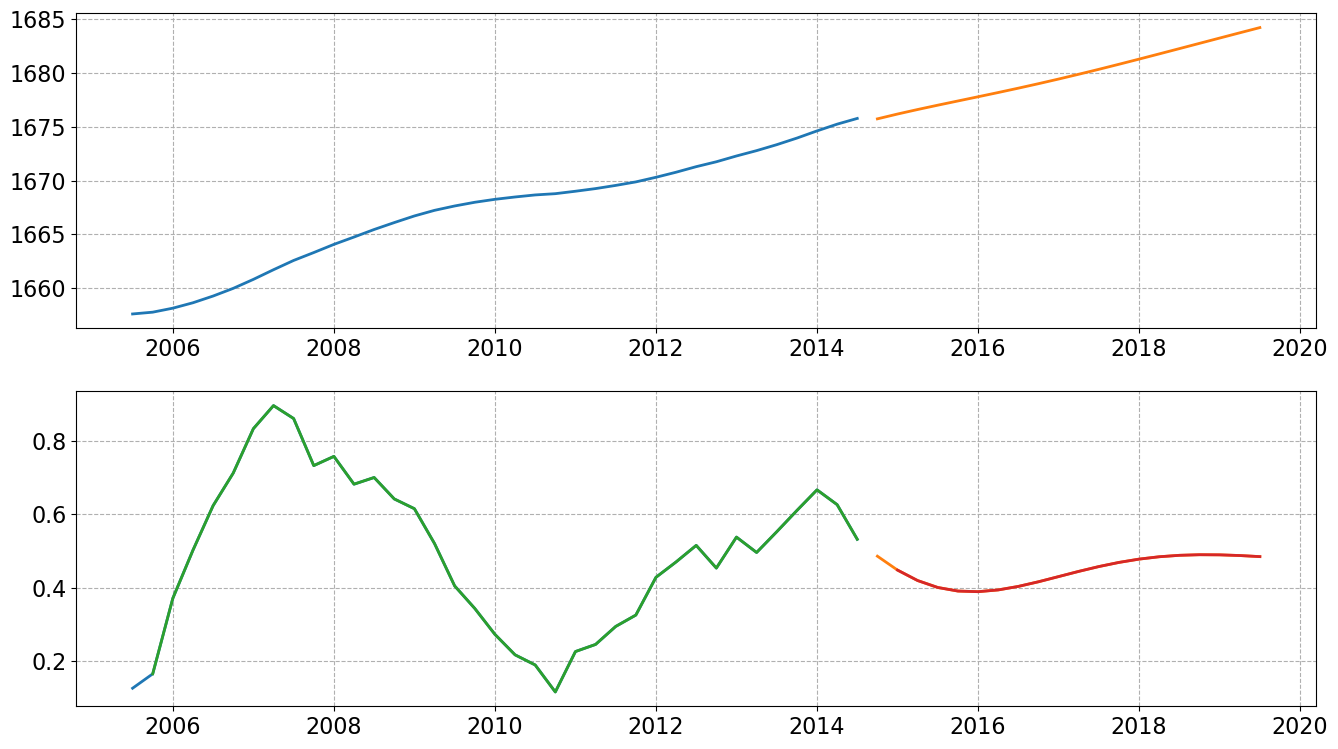

                   0
YEAR                
2014.75  1675.727214
2015.00  1676.175543
2015.25  1676.595371
2015.50  1676.996351
2015.75  1677.387609
2016.00  1677.777148
2016.25  1678.171460
2016.50  1678.575336
2016.75  1678.991847
2017.00  1679.422458
2017.25  1679.867245
2017.50  1680.325177
2017.75  1680.794419
2018.00  1681.272641
2018.25  1681.757298
2018.50  1682.245873
2018.75  1682.736061
2019.00  1683.225908
2019.25  1683.713885
2019.50  1684.198924


In [9]:
min_val, max_val, scale = transformer_df[target]

train_result = ari.get_prediction(p+d, train_size-1)
Gtrain  = train_result.predicted_mean # * scale + min_val

test_result = ari.get_prediction(train_size, train_size+test_size-1)
Gtest  = test_result.predicted_mean # * scale + min_val

# integrate
train0_epoch = train_df.index[d+p-1] # = train[d].index[p-1]
test0_epoch  = 2014.50 # = train[d].index[-1]"
print(train0_epoch, test0_epoch)

l = 1
train_value1 = integrate(diff[d-l][target].loc[train0_epoch], Gtrain)
test_value1  = integrate(diff[d-l][target].loc[test0_epoch],  Gtest)


display(diff[d-1][target].loc[train0_epoch])
pred_train = pd.DataFrame(train_value1, index=train_df.index[d+p:])

display(display(diff[d-1][target].loc[test0_epoch]))
pred_test = pd.DataFrame(test_value1, index=test_df.index)

dy_train = pd.DataFrame(Gtrain, index=train_df.index[p+d:])
dy_test = pd.DataFrame(Gtest, index=test_df.index)

dy_train_c = pred_train.diff(1, "index").dropna()
dy_test_c  = pred_test.diff(1, "index").dropna()

fig, ax = plt.subplots(2, 1, figsize=(16, 9))

ax[0].plot(pred_train, label="predicted")
# ax.fill_between(train[d].index[s:], train_val+train_cov, train_val-train_cov, alpha=0.3, label="63% confidence interval")
ax[0].plot(pred_test, label="forevast")

ax[1].plot(dy_train, label="predicted")
ax[1].plot(dy_test, label="forecast")
ax[1].plot(dy_train_c, label="predicted_check")
ax[1].plot(dy_test_c, label="forecast_check")

plt.show()

print(pred_test)

# 学習・予測

### ignore stationality / invertibility

In [10]:
ps = [1, 2, 3, 4, 5]
ds = [0, 1, 2, 3, 4]

const_df = pd.DataFrame(index=ps, columns=ds)
sigma2_df = pd.DataFrame(index=ps, columns=ds)
mse_df = pd.DataFrame(index=ps, columns=ds)
llf_df = pd.DataFrame(index=ps, columns=ds)
aic_df = pd.DataFrame(index=ps, columns=ds)

ave_dP_df = pd.DataFrame(index=ps, columns=ds)
end_dP_df = pd.DataFrame(index=ps, columns=ds)

sigma2_df.fillna(0, inplace=True)
const_df.fillna(0, inplace=True)
mse_df.fillna(0, inplace=True)

llf_df.fillna(0, inplace=True)
aic_df.fillna(0, inplace=True)

ave_dP_df.fillna(0, inplace=True)
end_dP_df.fillna(0, inplace=True)

for p in ps:
    for d in ds:

        modeldir = "../models/1214_SARIMAX_heatmap/"
        pred_train = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
        pred_test  = pd.DataFrame(index=test_df.index, columns=test_df.columns)

        for target in train_df.columns:
            print(p, d, target)

            ari = sm.tsa.SARIMAX(train_df[target].values,
                                order=(p, d, 0), trend="c", 
                                enforce_stationarity=False, enforce_invertibility=False, 
                                simple_differencing=True, # the prediction results are for differenced series
                                Hamilton_representation=True, # simple_differencing must be =True
                                ).fit(maxiter=1000, disp=False)
            
            ari.save(modeldir + target + ".pkl")
            const_df.loc[p, d] += ari.params[0] # * scale + min_val
            sigma2_df.loc[p, d] += ari.params[-1]
            mse_df.loc[p, d] += ari.mse
            llf_df.loc[p, d] += ari.llf
            aic_df.loc[p, d] += ari.aic


            # train_result = ari.get_prediction(p+d, train_size-1)
            # test_result = ari.get_prediction(train_size, train_size+test_size-1)
            train_result = ari.get_prediction(p+1, train_size-d)
            test_result = ari.get_prediction(train_size+1-d, train_size+test_size-d)


            # min_val, max_val, scale = transformer_df[target]
            Gtrain  = train_result.predicted_mean # * scale + min_val
            Gtest  = test_result.predicted_mean # * scale + min_val

            # integrate
            train0_epoch = train_df.index[d+p-1] # = train[d].index[p-1]
            test0_epoch  = 2014.50 # = train[d].index[-1]"
            for l in range(1, d+1):
                Gtrain = integrate(diff[d-l][target].loc[train0_epoch], Gtrain)
                Gtest  = integrate(diff[d-l][target].loc[test0_epoch],  Gtest)

            pred_train[target] = Gtrain
            pred_test[target]  = Gtest


        # J = len(train_df.columns) # number of gauss coeficients
        # const_df.loc[p, d] /= J
        # mse_df.loc[p, d] /= J
        # llf_df.loc[p, d] /= J
        # aic_df.loc[p, d] /= J

        ### get dP_n(t)
        epochs = pred_test.index
        gnames = pred_test.columns

        dP = np.zeros((len(epochs), 14), dtype=float) # n==0 is dummy
        for i, epoch in enumerate(epochs):
            # print(epoch)
            for target in gnames:
                n = int(target[2:].split(",")[0])
                dP[i, n] += (n+1) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target]) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target])
        
        dP = np.delete(dP, [0, 9, 10, 11, 12, 13], axis=1) # n==0 is dummy
        # print(dP)
        dPsum = np.sum(dP, axis=1)

        ave = np.average(np.sqrt(dPsum))
        y10 = np.sqrt(dPsum[-1])
        ave_dP_df.loc[p, d] = ave
        end_dP_df.loc[p, d] = y10


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['Hamilton_representation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


1 0 g(1, 0)
1 0 g(1, 1)
1 0 h(1, 1)
1 0 g(2, 0)
1 0 g(2, 1)
1 0 h(2, 1)
1 0 g(2, 2)
1 0 h(2, 2)
1 0 g(3, 0)
1 0 g(3, 1)
1 0 h(3, 1)
1 0 g(3, 2)
1 0 h(3, 2)
1 0 g(3, 3)
1 0 h(3, 3)
1 0 g(4, 0)
1 0 g(4, 1)
1 0 h(4, 1)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


1 0 g(4, 2)
1 0 h(4, 2)
1 0 g(4, 3)
1 0 h(4, 3)
1 0 g(4, 4)
1 0 h(4, 4)
1 0 g(5, 0)
1 0 g(5, 1)
1 0 h(5, 1)
1 0 g(5, 2)
1 0 h(5, 2)
1 0 g(5, 3)
1 0 h(5, 3)
1 0 g(5, 4)
1 0 h(5, 4)
1 0 g(5, 5)
1 0 h(5, 5)
1 0 g(6, 0)
1 0 g(6, 1)
1 0 h(6, 1)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

5 4 g(13, 4)
5 4 h(13, 4)
5 4 g(13, 5)
5 4 h(13, 5)
5 4 g(13, 6)
5 4 h(13, 6)
5 4 g(13, 7)
5 4 h(13, 7)
5 4 g(13, 8)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

5 4 h(13, 8)
5 4 g(13, 9)
5 4 h(13, 9)
5 4 g(13, 10)
5 4 h(13, 10)
5 4 g(13, 11)
5 4 h(13, 11)
5 4 g(13, 12)
5 4 h(13, 12)
5 4 g(13, 13)
5 4 h(13, 13)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## const と sigma は共有？

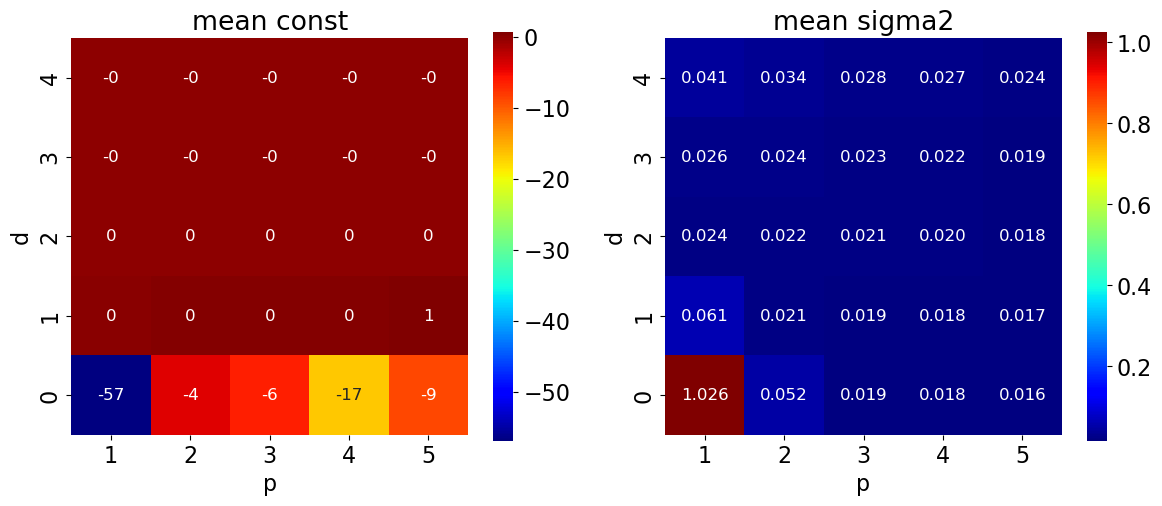

In [11]:
J = len(train_df.columns) # number of gauss coeficients

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(const_df.T, cmap='jet', annot=True, fmt='.0f', annot_kws={'size': 12}, square=True, ax=ax[0])
sns.heatmap(sigma2_df.T, cmap='jet', annot=True, fmt='.3f', annot_kws={'size': 12}, square=True, ax=ax[1])

ax[0].grid(False)
ax[1].grid(False)

ax[0].set_title("mean const")
ax[1].set_title("mean sigma2")

ax[0].set_xlabel("p")
ax[1].set_xlabel("p")

ax[0].set_ylabel("d")
ax[1].set_ylabel("d")
ax[0].invert_yaxis()
ax[1].invert_yaxis()

plt.tight_layout()

plt.savefig(savedir + "const_sigma2_heatmap.png")
plt.show()

#### ~~Wow! 仮説通り！！ const は一様！~~

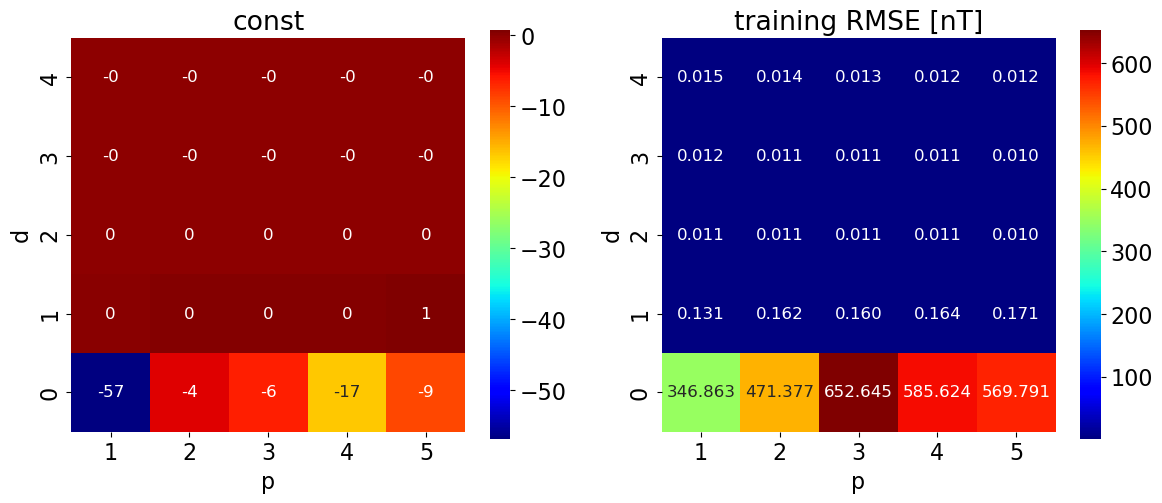

In [12]:
J = len(train_df.columns) # number of gauss coeficients

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(const_df.T, cmap='jet', annot=True, fmt='.0f', annot_kws={'size': 12}, square=True, ax=ax[0])
sns.heatmap(np.sqrt(mse_df/J).T, cmap='jet', annot=True, fmt='.3f', annot_kws={'size': 12}, square=True, ax=ax[1])

ax[0].grid(False)
ax[1].grid(False)

ax[0].set_title("const")
ax[1].set_title("training RMSE [nT]")

ax[0].set_xlabel("p")
ax[1].set_xlabel("p")

ax[0].set_ylabel("d")
ax[1].set_ylabel("d")
ax[0].invert_yaxis()
ax[1].invert_yaxis()

plt.tight_layout()

plt.savefig(savedir + "const_rmse_heatmap.png")
plt.show()

## AIC, ~~BIC~~ Log-LikelihoodFunction

色のつき方が p + d = 一定 の線に沿って縞々模様になっている。
例えばAICを見ると、縦、横に進むと O(10) ほど変わるのに、斜めに進むと 0(1) で変わる

→ ARI(p, d) は AR(p+d) モデルで表現できるから。

p + d = 一定 の線上では、p が増えるほど性能がいい
→ パラメータ数が増えて自由度が上がるから。

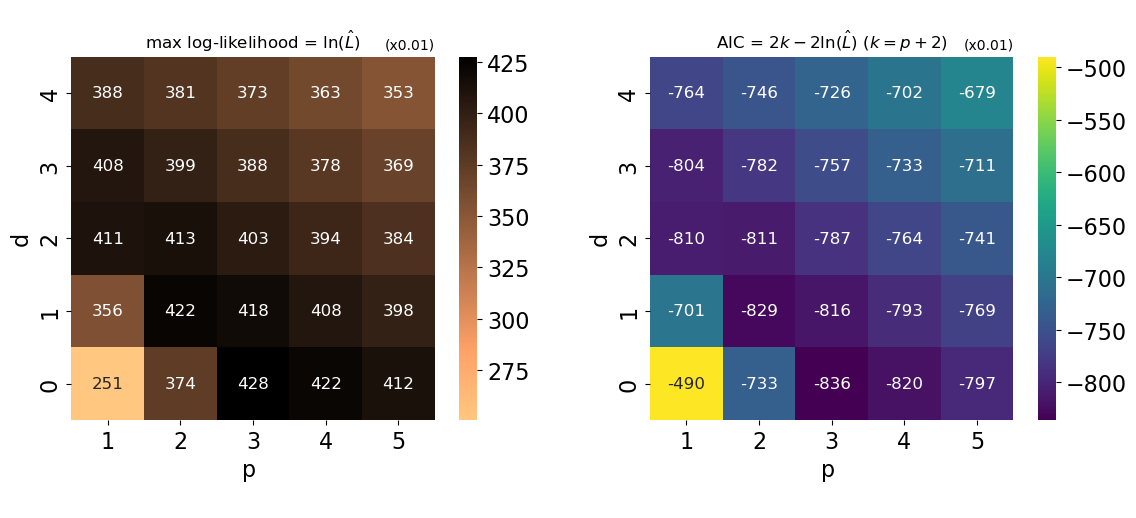

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(llf_df.T/100, cmap='copper_r', annot=True, fmt='.0f', annot_kws={'size': 12}, square=True, ax=ax[0])
sns.heatmap(aic_df.T/100, cmap='viridis', annot=True, fmt='.0f', annot_kws={'size': 12}, square=True, ax=ax[1])

ax[0].set_title("\n" + r"max log-likelihood = $\ln (\hat{L})$"        , fontsize=12)
ax[1].set_title("\n" + r"AIC = $2k - 2 \ln (\hat{L}) \ (k = p + 2)$", fontsize=12)

ax[0].set_title("(x0.01)", loc="right", fontsize=10)
ax[1].set_title("(x0.01)", loc="right", fontsize=10)

ax[0].grid(False)
ax[1].grid(False)

ax[0].set_xlabel("p \n")
ax[1].set_xlabel("p \n")

ax[0].set_ylabel("d")
ax[1].set_ylabel("d")
ax[0].invert_yaxis()
ax[1].invert_yaxis()

plt.tight_layout()

plt.savefig(savedir + "llf_aic_heatmap.png")
plt.show()

# $\sqrt{dP}$

d = 4 の範囲は著しく悪化 → 過剰差分をとっている（情報が失われている）

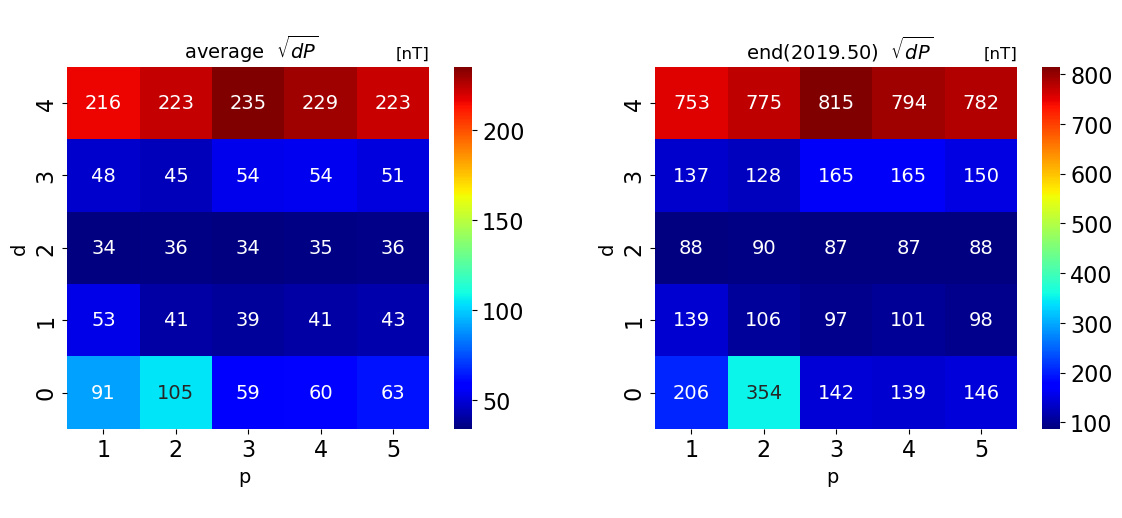

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(ave_dP_df.T, cmap='jet', annot=True, fmt='.0f', annot_kws={'size': 14}, square=True, ax=ax[0])
sns.heatmap(end_dP_df.T, cmap='jet', annot=True, fmt='.0f', annot_kws={'size': 14}, square=True, ax=ax[1])

ax[0].set_title("\n average " + r" $\sqrt{dP}$"     , fontsize=14)
ax[1].set_title("\n end(2019.50) " + r" $\sqrt{dP}$", fontsize=14)

ax[0].set_title("[nT]", loc="right", fontsize=12)
ax[1].set_title("[nT]", loc="right", fontsize=12)


ax[0].grid(False)
ax[1].grid(False)

ax[0].set_xlabel("p \n", fontsize=14)
ax[1].set_xlabel("p \n", fontsize=14)

ax[0].set_ylabel("d", fontsize=14)
ax[1].set_ylabel("d", fontsize=14)
ax[0].invert_yaxis()
ax[1].invert_yaxis()

plt.tight_layout()
plt.savefig(savedir + "dP_heatmap.png")
plt.show()

## 結論

AIC, BIC としては、

1. p + d = 3
2. p + d = 4

あたりが最適

$\sqrt{dP}$ としては

1. d = 2
2. d = 1

あたりが最適

なので...

1. (p, d) = (1, 2)
2. (p, d) = (2, 2)
3. (p, d) = (2, 1)

が最適パラメータか

# ARI(1, 2)

In [15]:
p, d = 1, 2

modeldir = "../models/1214_SARIMAX_heatmap/"
weights_df = pd.DataFrame(index=["intercept", "L1", "sigma2"], columns=train_df.columns)
pred_train = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
cov_train  = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
pred_test  = pd.DataFrame(index=test_df.index, columns=test_df.columns)
cov_test   = pd.DataFrame(index=test_df.index, columns=test_df.columns)

d1g_train = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
d1g_test  = pd.DataFrame(index=test_df.index, columns=test_df.columns)
d1c_test  = pd.DataFrame(index=test_df.index, columns=test_df.columns)

d2g_train = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
d2g_test  = pd.DataFrame(index=test_df.index, columns=test_df.columns)
d2c_train  = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
d2c_test   = pd.DataFrame(index=test_df.index, columns=test_df.columns)

for target in train_df.columns:
    print(target)

    ari = sm.tsa.SARIMAX(train_df[target].values,
                        order=(p, d, 0), 
                        trend='c', 
                        enforce_stationarity=False, enforce_invertibility=False, 
                        simple_differencing=True, # the prediction results are for differenced series
                        Hamilton_representation=True, # simple_differencing must be =True
                        ).fit(maxiter=1000, disp=False)
    
    ari.save(modeldir + target + "best.pkl")
    weights_df[target] = ari.params

    train_result = ari.get_prediction(p+1, train_size-d)
    test_result = ari.get_prediction(train_size+1-d, train_size+test_size-d)

    Gtrain = np.zeros((d+1, train_size-p-d))
    Gtest  = np.zeros((d+1, test_size))
    Ctrain = np.zeros((d+1, train_size-p-d))
    Ctest  = np.zeros((d+1, test_size))
    # min_val, max_val, scale = transformer_df[target]
    Gtrain[0, :]  = train_result.predicted_mean # * scale + min_val
    Gtest[0, :]  = test_result.predicted_mean # * scale + min_val
    Ctrain[0, :] = train_result.se_mean # * scale
    Ctest[0, :]  = test_result.se_mean # * scale

    # integrate
    train0_epoch = train_df.index[d+p-1] # = train[d].index[p-1]
    test0_epoch  = 2014.50 # = train[d].index[-1]"
    for l in range(1, d+1):
        # Gtrain[l, :] = integrate(diff[d-l][target].loc[train0_epoch], Gtrain[l-1, :])
        Gtrain[l, :] = diff[d-l][target].loc[train0_epoch:test0_epoch-0.25] + Gtrain[l-1, :]
        # Ctrain[l, :] = integrate(diff[d-l][target].loc[train0_epoch], Ctrain[l-1, :])
        Gtest[l, :]  = integrate(diff[d-l][target].loc[test0_epoch],  Gtest[l-1, :])
        Ctest[l, :]  = integrate(0,  Ctest[l-1, :])

    pred_train[target] = Gtrain[d, :]
    cov_train[target]  = Ctrain[d, :]
    d1g_train[target]  = Gtrain[1, :]
    d2g_train[target]  = Gtrain[0, :]
    d2c_train[target]= Ctrain[0, :]

    pred_test[target]  = Gtest[d, :]
    cov_test[target]   = Ctest[d, :]
    d1g_test[target]   = Gtest[1, :]
    d1c_test[target]   = Ctest[1, :]
    d2g_test[target]   = Gtest[0, :]
    d2c_test[target] = Ctest[0, :]


g(1, 0)
g(1, 1)
h(1, 1)
g(2, 0)
g(2, 1)
h(2, 1)
g(2, 2)
h(2, 2)
g(3, 0)
g(3, 1)
h(3, 1)
g(3, 2)
h(3, 2)
g(3, 3)
h(3, 3)
g(4, 0)
g(4, 1)
h(4, 1)
g(4, 2)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['Hamilton_representation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


h(4, 2)
g(4, 3)
h(4, 3)
g(4, 4)
h(4, 4)
g(5, 0)
g(5, 1)
h(5, 1)
g(5, 2)
h(5, 2)
g(5, 3)
h(5, 3)
g(5, 4)
h(5, 4)
g(5, 5)
h(5, 5)
g(6, 0)
g(6, 1)
h(6, 1)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

g(6, 2)
h(6, 2)
g(6, 3)
h(6, 3)
g(6, 4)
h(6, 4)
g(6, 5)
h(6, 5)
g(6, 6)
h(6, 6)
g(7, 0)
g(7, 1)
h(7, 1)
g(7, 2)
h(7, 2)
g(7, 3)
h(7, 3)
g(7, 4)
h(7, 4)
g(7, 5)


...

/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

g(13, 4)
h(13, 4)
g(13, 5)
h(13, 5)
g(13, 6)
h(13, 6)
g(13, 7)
h(13, 7)
g(13, 8)
h(13, 8)
g(13, 9)
h(13, 9)
g(13, 10)
h(13, 10)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

g(13, 11)
h(13, 11)
g(13, 12)
h(13, 12)
g(13, 13)
h(13, 13)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

In [16]:
print(ari.mse)
print(np.sqrt(ari.params[-1]))
display(ari.summary())
display(weights_df)

2.6002950015029887e-09
3.5833307794396714e-05


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   D2.y   No. Observations:                   38
Model:               SARIMAX(1, 0, 0)   Log Likelihood                 326.255
Date:                Fri, 15 Dec 2023   AIC                           -646.509
Time:                        03:53:45   BIC                           -641.677
Sample:                             0   HQIC                          -644.806
                                 - 38                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -8.272e-06   6.38e-06     -1.297      0.195   -2.08e-05    4.23e-06
ar.L1          1.0023   1.29e-09   7.77e+08      0.000       1.002       1.002
sigma2      1.284e-09   6.36e-10      2.017      0.044    3.66e-11    2.53e-09
===================================================================================
Ljung-Box (L1) (Q):                   7.99   Jarque-Bera (JB):                 2.72
Prob(Q):                              0.00   Prob(JB):                         0.26
Heteroskedasticity (H):               0.45   Skew:                             0.65
Prob(H) (two-sided):                  0.18   Kurtosis:                         3.30
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.52e+24. Standard errors may be unstable.
"""

coef,"g(1, 0)","g(1, 1)","h(1, 1)","g(2, 0)","g(2, 1)","h(2, 1)","g(2, 2)","h(2, 2)","g(3, 0)","g(3, 1)",...,"g(13, 9)","h(13, 9)","g(13, 10)","h(13, 10)","g(13, 11)","h(13, 11)","g(13, 12)","h(13, 12)","g(13, 13)","h(13, 13)"
intercept,-0.004894,0.003344,-0.002123,0.014309,0.001447,-0.007420,-0.000383,-0.007855,0.007347,-0.004493,...,4.055922e-06,-1.064603e-05,-2.013088e-05,8.045435e-06,9.861702e-07,-3.413200e-06,-2.223431e-05,-8.740835e-06,-1.396576e-05,-8.271688e-06
L1,0.523502,0.634021,0.899507,0.257478,0.717403,0.742303,0.839203,0.782872,0.680759,0.530896,...,9.657929e-01,1.001187e+00,9.976282e-01,9.700292e-01,9.843442e-01,9.746781e-01,1.019588e+00,1.012686e+00,1.004639e+00,1.002287e+00
sigma2,0.002211,0.004751,0.002450,0.000470,0.001042,0.002084,0.001492,0.001548,0.000365,0.000409,...,1.918984e-09,2.336919e-09,1.287364e-09,2.212821e-09,1.517709e-09,2.341555e-09,1.557809e-09,2.062185e-09,1.211345e-09,1.284026e-09


# plot results

### magpred

In [17]:
#outtype = ".eps"
outtype = ".png"

i2015data = np.loadtxt("../models/igrf2015.dat")
i2020data = np.loadtxt("../models/igrf2020.dat")

# print(i2005data[0,:])
# print(i2005data[1,:])

i2015data[1,:] = i2015data[0,:] + 5.0 * i2015data[1,:]
i2015data[1,0] = 2015.0
i2015data[1,0] = 2020.0
# print(i2015data)

i2020data[1,:] = i2020data[0,:] + 5.0 * i2020data[1,:]
i2020data[1,0] = 2020.0
i2020data[1,0] = 2025.0
# print(i2025data)

def plot_result(axis, coef_idx, target):

    # igrf2015 (comparison)
    axis.plot   ( i2015data[:,0],          i2015data[:,coef_idx],         color='green') # SV
    axis.scatter( i2015data[0,0],          i2015data[0,coef_idx],         color='green', label="IGRF2015", marker='*', s=200, edgecolors='black' )
    # igrf2020 (comparison)
    # axis.plot   ( i2020data[:,0],          i2020data[:,coef_idx],         color='olive') # SV
    axis.scatter( i2020data[0,0],          i2020data[0,coef_idx],         color='olive', label="IGRF2020", marker='*', s=200, edgecolors='black' )

    coef_df[target].plot(ax=axis, color='black'  , label="Original")   # Vincent data (true)

    axis.plot(pred_train.index, pred_train[target], color='red', linewidth=1) # predict (AR(2))
    # axis.fill_between(pred_train.index, pred_train[target]-cov_train[target], pred_train[target]+cov_train[target], color='orange', alpha=0.5)

    pred_test[target].plot(ax=axis, color='red' , label="AR prediction") # predict (AR(2))
    axis.fill_between(pred_test.index, pred_test[target]-cov_test[target], pred_test[target]+cov_test[target], color='orange', alpha=0.5) # 1 sigma ~= 68.3%


    axis.set_ylabel("g  [nT]")
    axis.set_xticks(np.arange(2005, 2021, 5))
    axis.grid()

def plot_dg(axis, d, dg_train, dg_test, target):
    
    (diff[d] * 4**d)[target].plot(ax=axis, color='black'  , label="Original")   # Vincent data (true)
    
    axis.plot(dg_train.index, dg_train[target], color='red', linewidth=1) # predict (AR(2))
    dg_test[target].plot(ax=axis, color='red' , label="AR prediction") # predict (AR(2))

    axis.set_ylabel(f"$\Delta^{d} g / \Delta t ^{d}$  [nT/$yr^2$]")
    axis.set_xticks(np.arange(2005, 2021, 5))
    axis.grid()

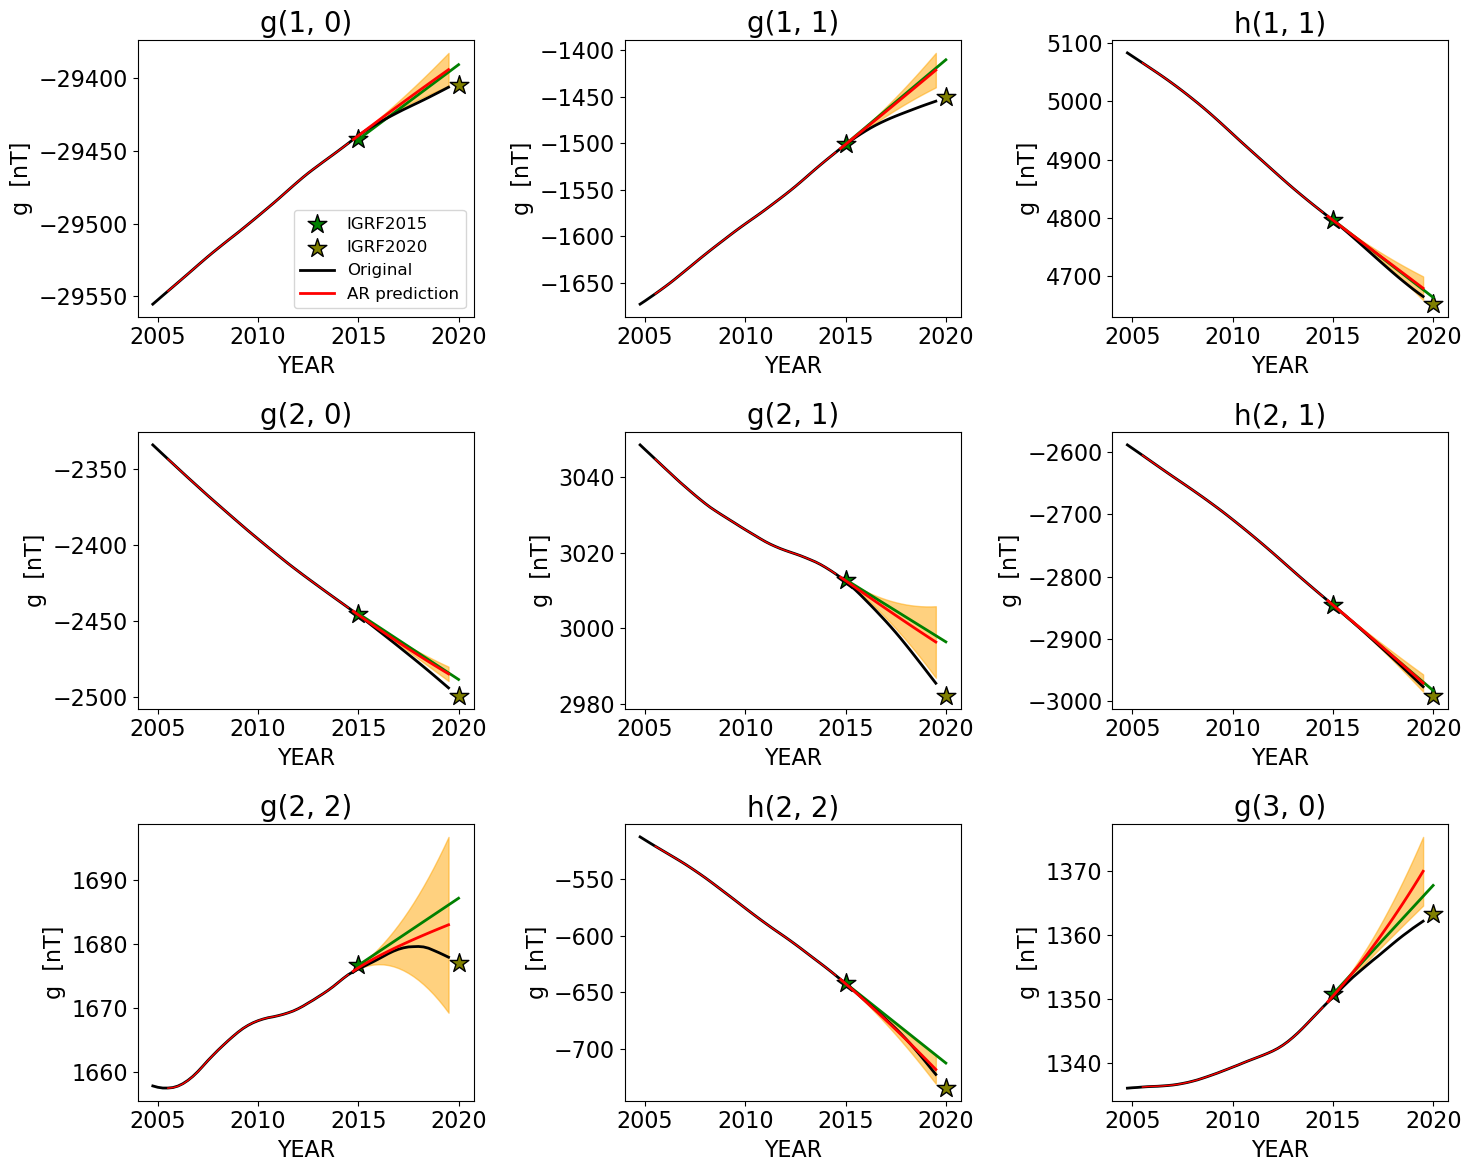

In [18]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    
    plot_result(ax, idx, target)
    ax.set_title(target, fontsize=20)

axes[0].legend(loc='lower right', fontsize=12)


plt.tight_layout()
plt.savefig(savedir + "magpred" + outtype)
plt.show()


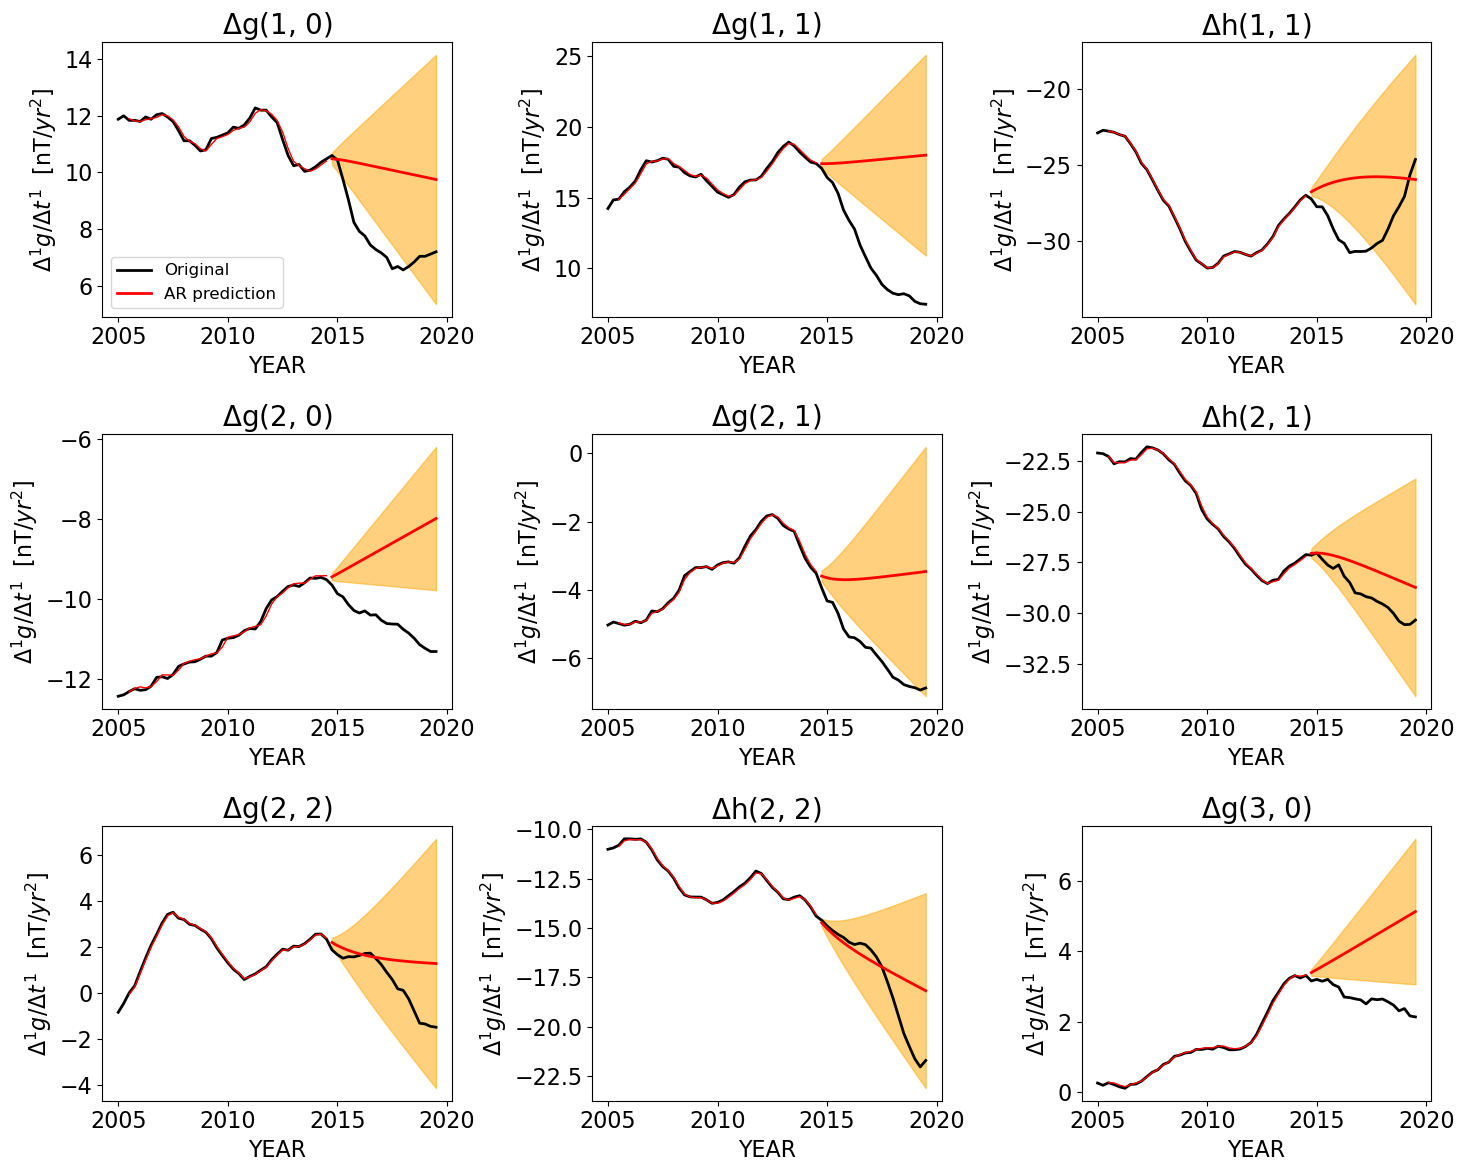

In [19]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_name = ["g(1,0)", "g(1,1)", "h(1,1)", "g(2,0)", "g(2,1)", "h(2,1)", "g(2,2)", "h(2,2)", "g(3,0)"]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

d1gdt_train = d1g_train * 4
d1gdt_test  = d1g_test  * 4
d1cdt_test  = d1c_test  * 4

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    ax.fill_between(d1gdt_test.index, d1gdt_test[target]-d1cdt_test[target], d1gdt_test[target]+d1cdt_test[target], color='orange', alpha=0.5) # 1 sigma ~= 68.3%
    
    plot_dg(ax, 1, d1gdt_train, d1gdt_test, target)
    ax.set_title(r"$\Delta$" + target, fontsize=20)


axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + "magpred_d1g" + outtype)
plt.show()


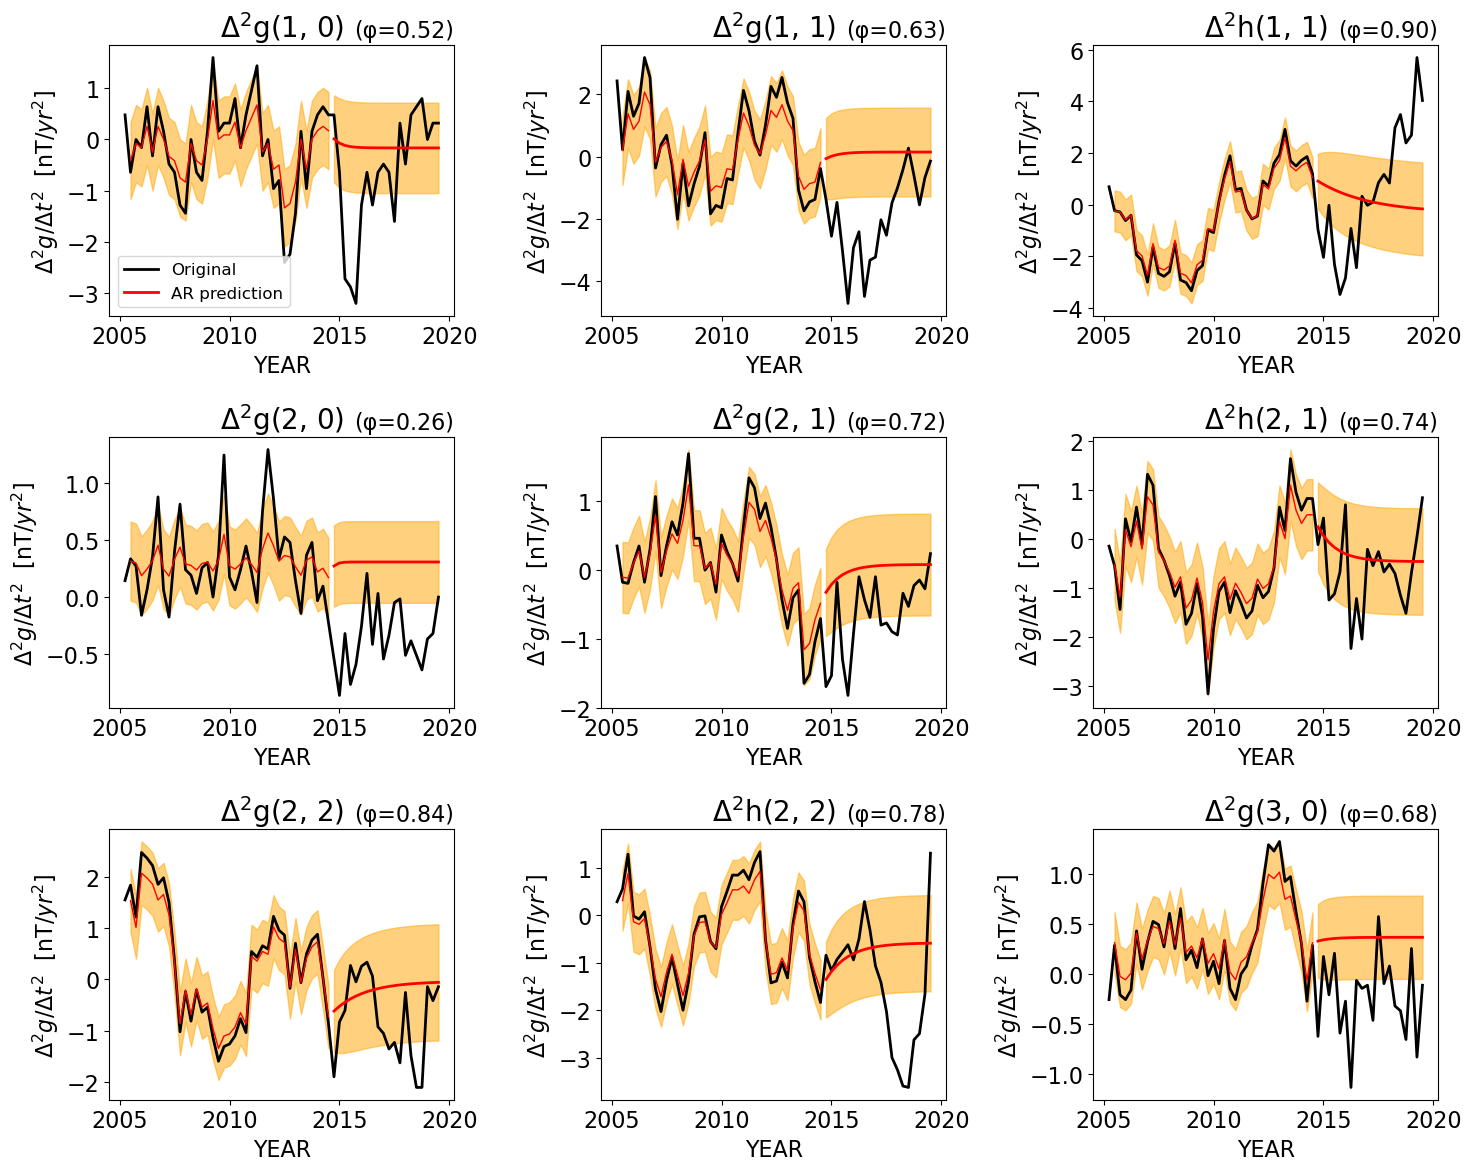

In [20]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

d2gdt_train = d2g_train * 4**2
d2gdt_test = d2g_test * 4**2
d2cdt_train = d2c_train * 4**2
d2cdt_test = d2c_test * 4**2

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    
    plot_dg(ax, 2, d2gdt_train, d2gdt_test, target)
    ax.fill_between(d2gdt_train.index, d2gdt_train[target]-d2cdt_train[target], d2gdt_train[target]+d2cdt_train[target], color='orange', alpha=0.5)
    ax.fill_between(d2gdt_test.index, d2gdt_test[target]-d2cdt_test[target], d2gdt_test[target]+d2cdt_test[target], color='orange', alpha=0.5) # 1 sigma ~= 68.3%

    ax.set_title(r"$\Delta^2$" + target, fontsize=20)
    ax.set_title(f"(φ={weights_df.loc['L1', target]:.2f})", loc="right", fontsize=16)


axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + "magpred_d2g" + outtype)
plt.show()


## $\sqrt{dP}$

2014.75
2015.0
2015.25
2015.5
2015.75
2016.0
2016.25
2016.5
2016.75
2017.0
2017.25
2017.5
2017.75
2018.0
2018.25
2018.5
2018.75
2019.0
2019.25
2019.5
[[4.27809303e-02 5.38472869e-02 7.08712278e-02 6.57858910e-03
  9.64015221e-03 6.02273278e-03 7.15926754e-03 5.29266717e-04]
 [5.51144615e-01 3.97215404e-01 5.04990622e-01 6.09131964e-02
  1.39156316e-01 4.77927630e-02 6.73892953e-02 5.51158115e-03]
 [2.04708639e+00 1.19989839e+00 1.56235728e+00 2.46908743e-01
  6.97809457e-01 1.97646371e-01 2.65457485e-01 2.74095527e-02]
 [6.55410798e+00 2.95055126e+00 3.35331847e+00 8.57115437e-01
  2.23811477e+00 6.11486569e-01 7.64456528e-01 9.40748473e-02]
 [1.86058000e+01 6.51730546e+00 6.52507600e+00 2.44920878e+00
  5.62489950e+00 1.53265057e+00 1.95061739e+00 2.48347330e-01]
 [4.19823888e+01 1.20004696e+01 1.08459925e+01 5.70814128e+00
  1.21832972e+01 3.28332621e+00 4.28458462e+00 5.32723346e-01]
 [7.89433834e+01 1.97812816e+01 1.69382551e+01 1.18894854e+01
  2.33666310e+01 6.33294940e+00 8.3517

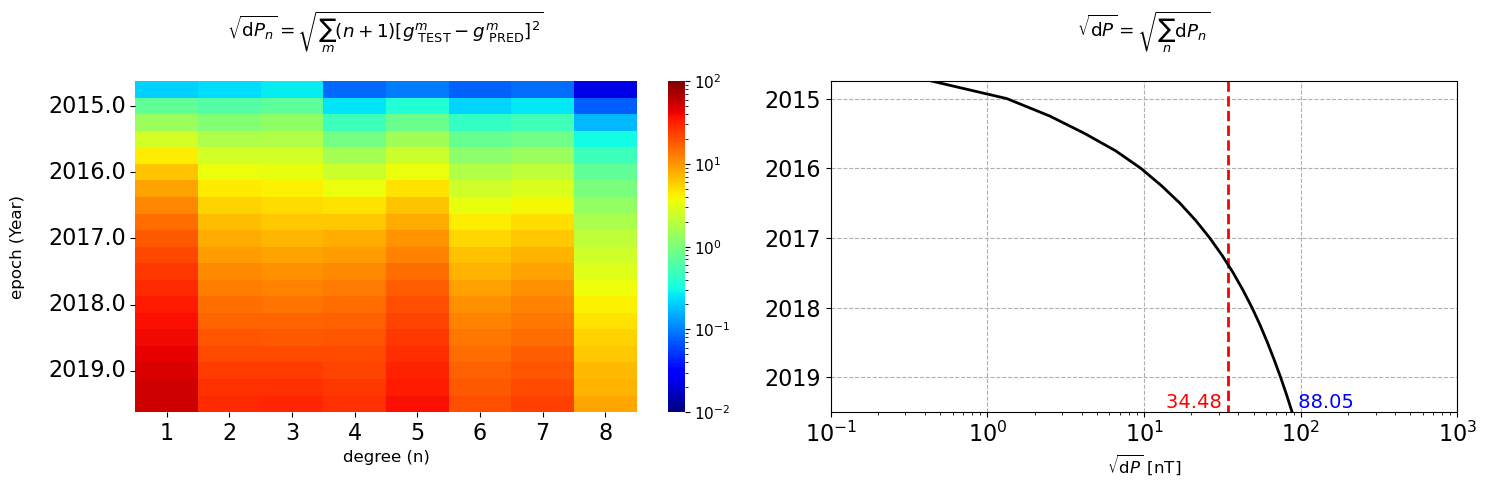

In [21]:
epochs = pred_test.index
gnames = pred_test.columns

### get dP_n(t)

dP = np.zeros((len(epochs), 14), dtype=float) # n==0 is dummy

for i, epoch in enumerate(epochs):
    print(epoch)

    for target in gnames:
        n = int(target[2:].split(",")[0])

        dP[i, n] += (n+1) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target]) * (pred_test.loc[epoch, target] - coef_df.loc[epoch, target])

dP = np.delete(dP, [0, 9, 10, 11, 12, 13], axis=1) # n==0 is dummy, ~~n >= 11 is not used~~
print(dP)

dP_df = pd.DataFrame(np.sqrt(dP), index=epochs, columns=range(1, 9))

print(dP_df)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plt.rcParams.update({
    'font.size'     : 11,
    })

sns.heatmap(dP_df, cmap='jet', norm=LogNorm(vmin=0.01, vmax=100), ax=ax[0])
ax[0].set_xlabel('degree (n)', fontsize=12)
ax[0].set_ylabel('epoch (Year)\n', fontsize=12)
ax[0].set_yticks(np.arange(1.5, len(epochs), 4), epochs[1::4])
ax[0].set_title(r"$\sqrt{\mathrm{d} P_n} = \sqrt{\sum_m (n+1) \left[ g_\mathrm{\ TEST}^{m} - g_\mathrm{\ PRED}^{m} \right]^2}$" + "\n")
ax[0].grid(False)

dPsum = np.sum(dP, axis=1)


ave = np.average(np.sqrt(dPsum))
y10 = np.sqrt(dPsum[-1])

print(ave)
print(y10)

ax[1].vlines(x=ave, ymin=epochs[0], ymax=epochs[-1], color="red", linestyle='--')
ax[1].text(ave, epochs[-1], f"{ave:.2f} ", ha='right', va='bottom', fontsize=14, color='red')
ax[1].text(y10, epochs[-1], f" {y10:.2f}", ha='left',  va='bottom', fontsize=14, color='blue')

ax[1].plot(np.sqrt(dPsum), epochs, c='k')
ax[1].set_xlabel(r"$\sqrt{\mathrm{d} P}$ [nT]", fontsize=12)
ax[1].set_xscale('log')
ax[1].set_xticks([0.1, 1, 10, 100, 1000])
ax[1].set_ylim(epochs[-1], epochs[0])
ax[1].set_yticks(epochs[1::4])
ax[1].set_title(r"$\sqrt{\mathrm{d} P} = \sqrt{\sum_n \mathrm{d} P_n}$" + "\n")

fig.tight_layout()
plt.savefig(savedir + "dP_diagram.png", dpi=300)
plt.show()

## phase portrate

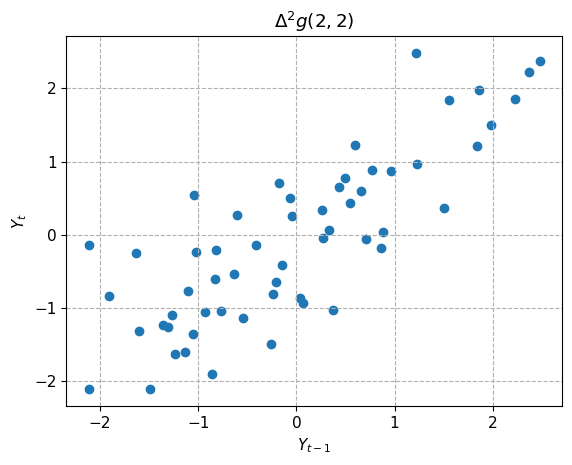

In [22]:
target = "g(2, 2)"
d = 2

orig_x = diff[d].iloc[:-1, :] * 4**d
orig_y = diff[d].iloc[1:, :] * 4**d

# display(orig_x)
# display(orig_y)

plt.scatter(orig_x[target], orig_y[target])
plt.title(f"$\Delta^{d} {target}$")

plt.xlabel(r"$Y_{t-1}$")
plt.ylabel(r"$Y_{t}$")

plt.show()

In [23]:
d = 2
orig_x = diff[d].iloc[:-1, :] * 4**d
orig_y = diff[d].iloc[1:, :] * 4**d

pred_x = d2g_test.iloc[:-1, :] * 4**d
pred_y = d2g_test.iloc[1:, :] * 4**d

def draw_vec(ax, x, y1, x2, y2):
    ax.quiver(x, y1, x2-x, y2-y1, angles='xy', scale_units='xy', scale=1, color='m', width=0.01)

def plot_phase_portrate(ax, target, zoom=False):
    minX, maxX = orig_x[target].min(), orig_x[target].max()
    X = np.linspace(minX, maxX, 100)

    ax.plot(X, 0*X, color='green', linewidth=0.5) # x軸(y=0)の描画
    ax.plot(X, X, color='green', linewidth=0.5) # y=xの描画

    # Original data
    ax.scatter(orig_x.loc[:2014.25, target], orig_y.loc[:2014.50, target], s=5, alpha=0.5, color='C0', label="Train")
    ax.scatter(orig_x.loc[2014.50:, target], orig_y.loc[2014.75:, target], s=5, alpha=0.5, color='C1', label="Test")

    # AR model
    phi = weights_df.loc["L1", target]
    const = weights_df.loc["intercept", target] * 4**d
    arY = phi * X + const
    ax.plot(X, arY, color='red', linewidth=2, label="AR model")
    pval_x, pval_y = pred_x[target].values, pred_y[target].values
    ax.scatter(pval_x, pval_y, s=10, alpha=1.0, color='red', label="AR prediction")

    # Web plot
    np.insert(pval_x, 0, orig_y.loc[2014.50, target])
    np.insert(pval_y, 0, pred_x.loc[2014.75, target])
    for i in range(test_size - 2):
        ax.plot([pval_x[i], pval_y[i]], [pval_y[i], pval_y[i]], color='m', linewidth=0.5)
        ax.plot([pval_y[i], pval_y[i]], [pval_y[i], pval_y[i+1]], color='m', linewidth=0.5)

    ax.set_xlabel(r"$Y_{t-1}$  [nT/$yr^2$]")
    ax.set_ylabel(r"$Y_{t}$  [nT/$yr^2$]")

    if zoom:
        for i in range(test_size - 2):
            draw_vec(ax, pval_x[i], pval_y[i], pval_y[i], pval_y[i])
            draw_vec(ax, pval_y[i], pval_y[i], pval_y[i], pval_y[i+1])
    
        zminX, zmaxX = min(0.95*min(pval_x), 1.1*min(pval_x)), max(0.9*max(pval_x), 1.1*max(pval_x))
        zminY, zmaxY = min(0.95*min(pval_y), 1.1*min(pval_y)), max(0.9*max(pval_y), 1.1*max(pval_y))
        ax.set_xlim(zminX, zmaxX)
        ax.set_ylim(zminY, zmaxY)

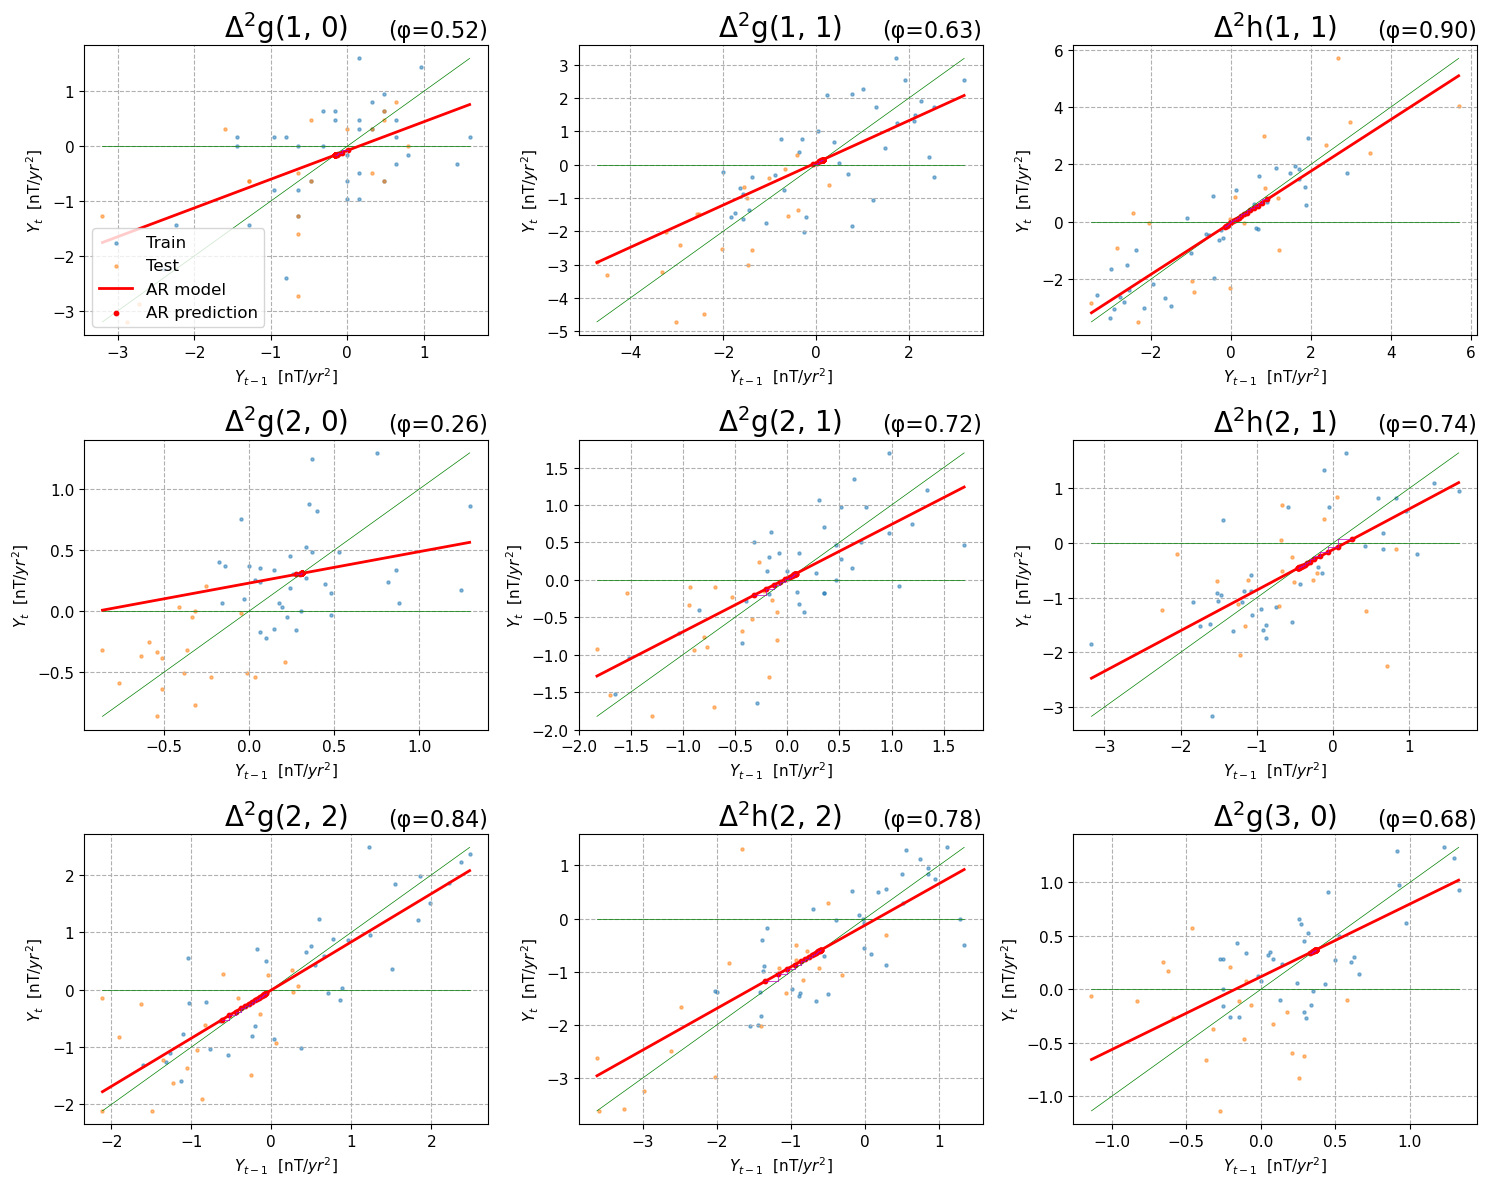

In [24]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    plot_phase_portrate(ax, target, zoom=False)
    
    ax.set_title(r"$\Delta^2$" + target, fontsize=20)
    ax.set_title(f"(φ={weights_df.loc['L1', target]:.2f})", loc="right", fontsize=16)

axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + "phase_portrate" + outtype)
plt.show()


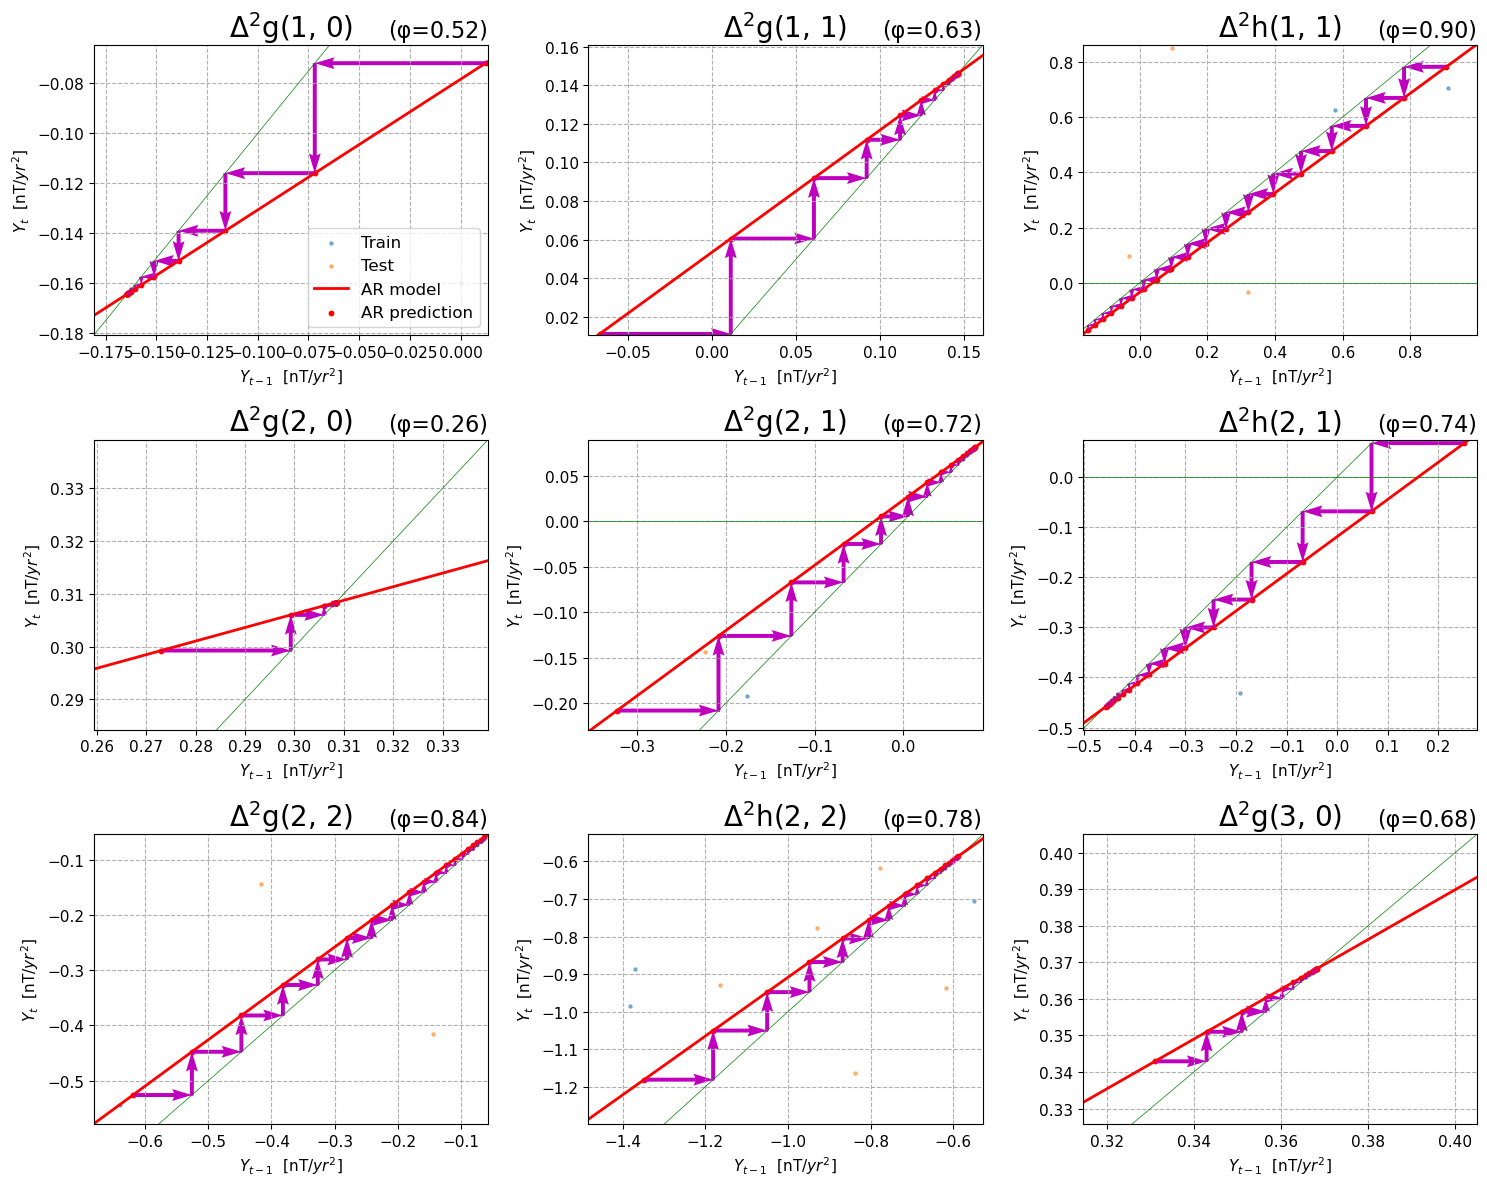

In [25]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    plot_phase_portrate(ax, target, zoom=True)
    
    ax.set_title(r"$\Delta^2$" + target, fontsize=20)
    ax.set_title(f"(φ={weights_df.loc['L1', target]:.2f})", loc="right", fontsize=16)

axes[0].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + "phase_portrate_zoom" + outtype)
plt.show()


# もしも、めちゃくちゃ伸ばすと...？

予測の期待値で考えると $E(\varepsilon_t) = 0$ だから

$g \approx \mathrm{ARI}(1, 2)$ <br>
$\iff E(\ddot{g}_t) = E(c + \varepsilon_t + \phi_1 \ddot{g}_{t-1}) = c + \phi_1 E(\ddot{g}_{t-1}) = \cdots = c (1 + \phi_1 + \phi_1^2 + \cdots + \phi_1^{~t-1}) + \phi_1^{~t} E(\ddot{g}_0)$

つまり、

- g の3階微分が、t=0 を起点とした指数関数である、という近似を行っている。
- |φ| < 1 なら、$t \rightarrow \infty$ で $E(\ddot{g}_t) \rightarrow \frac{c}{1 - \phi}$ だから、ガウス係数の予測値は二次関数に収束する？
- |φ| > 1 なら、$t \rightarrow \infty$ で $E(\ddot{g}_t) \rightarrow \infty$ だから、ガウス係数の予測値は発散する？

In [26]:
p, d = 1, 2

ex_test = np.arange(2014.75, 2074.75, 0.25)
test_size = len(ex_test)
print(test_size)

weights_df = pd.DataFrame(index=["intercept", "L1", "sigma2"], columns=train_df.columns)

pred_train = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
pred_test  = pd.DataFrame(index=ex_test, columns=test_df.columns)
cov_test   = pd.DataFrame(index=ex_test, columns=test_df.columns)

d2g_train = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
d2g_test  = pd.DataFrame(index=ex_test, columns=test_df.columns)
d2c_train  = pd.DataFrame(index=train_df.index[p+d:], columns=train_df.columns)
d2c_test   = pd.DataFrame(index=ex_test, columns=test_df.columns)

for target in train_df.columns:
    print(target)

    ari = sm.tsa.SARIMAX(train_df[target].values,
                        order=(p, d, 0), 
                        trend='c', 
                        enforce_stationarity=False, enforce_invertibility=False, 
                        simple_differencing=True, # the prediction results are for differenced series
                        Hamilton_representation=True, # simple_differencing must be =True
                        ).fit(maxiter=1000, disp=False)
    
    # ari.save(modeldir + target + "best.pkl")
    weights_df[target] = ari.params

    train_result = ari.get_prediction(p+1, train_size-d)
    test_result = ari.get_prediction(train_size+1-d, train_size+test_size-d)

    Gtrain = np.zeros((d+1, train_size-p-d))
    Gtest  = np.zeros((d+1, test_size))
    Ctrain = np.zeros((d+1, train_size-p-d))
    Ctest  = np.zeros((d+1, test_size))
    # min_val, max_val, scale = transformer_df[target]
    Gtrain[0, :]  = train_result.predicted_mean # * scale + min_val
    Gtest[0, :]  = test_result.predicted_mean # * scale + min_val
    Ctrain[0, :] = train_result.se_mean # * scale
    Ctest[0, :]  = test_result.se_mean # * scale

    # integrate
    train0_epoch = train_df.index[d+p-1] # = train[d].index[p-1]
    test0_epoch  = 2014.50 # = train[d].index[-1]"
    for l in range(1, d+1):
        # Gtrain[l, :] = integrate(diff[d-l][target].loc[train0_epoch], Gtrain[l-1, :])
        Gtrain[l, :] = diff[d-l][target].loc[train0_epoch:test0_epoch-0.25] + Gtrain[l-1, :]
        # Ctrain[l, :] = integrate(diff[d-l][target].loc[train0_epoch], Ctrain[l-1, :])
        Gtest[l, :]  = integrate(diff[d-l][target].loc[test0_epoch],  Gtest[l-1, :])
        Ctest[l, :]  = integrate(0,  Ctest[l-1, :])

    pred_train[target] = Gtrain[d, :]
    d2g_train[target]  = Gtrain[0, :]
    d2c_train[target]= Ctrain[0, :]

    pred_test[target]  = Gtest[d, :]
    cov_test[target]   = np.ones(len(Ctest[d, :])) * 0.00000001
    d2g_test[target]   = Gtest[0, :]
    d2c_test[target] = Ctest[0, :]

240
g(1, 0)
g(1, 1)
h(1, 1)
g(2, 0)
g(2, 1)
h(2, 1)
g(2, 2)
h(2, 2)
g(3, 0)
g(3, 1)
h(3, 1)
g(3, 2)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['Hamilton_representation']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


h(3, 2)
g(3, 3)
h(3, 3)
g(4, 0)
g(4, 1)
h(4, 1)
g(4, 2)
h(4, 2)
g(4, 3)
h(4, 3)
g(4, 4)
h(4, 4)
g(5, 0)
g(5, 1)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

h(5, 1)
g(5, 2)
h(5, 2)
g(5, 3)
h(5, 3)
g(5, 4)
h(5, 4)
g(5, 5)
h(5, 5)
g(6, 0)
g(6, 1)
h(6, 1)
g(6, 2)
h(6, 2)


...

/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

g(13, 7)
h(13, 7)
g(13, 8)
h(13, 8)
g(13, 9)
h(13, 9)
g(13, 10)
h(13, 10)
g(13, 11)
h(13, 11)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/minif

g(13, 12)
h(13, 12)
g(13, 13)
h(13, 13)


/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/satosho/miniforge3/envs/DS2/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


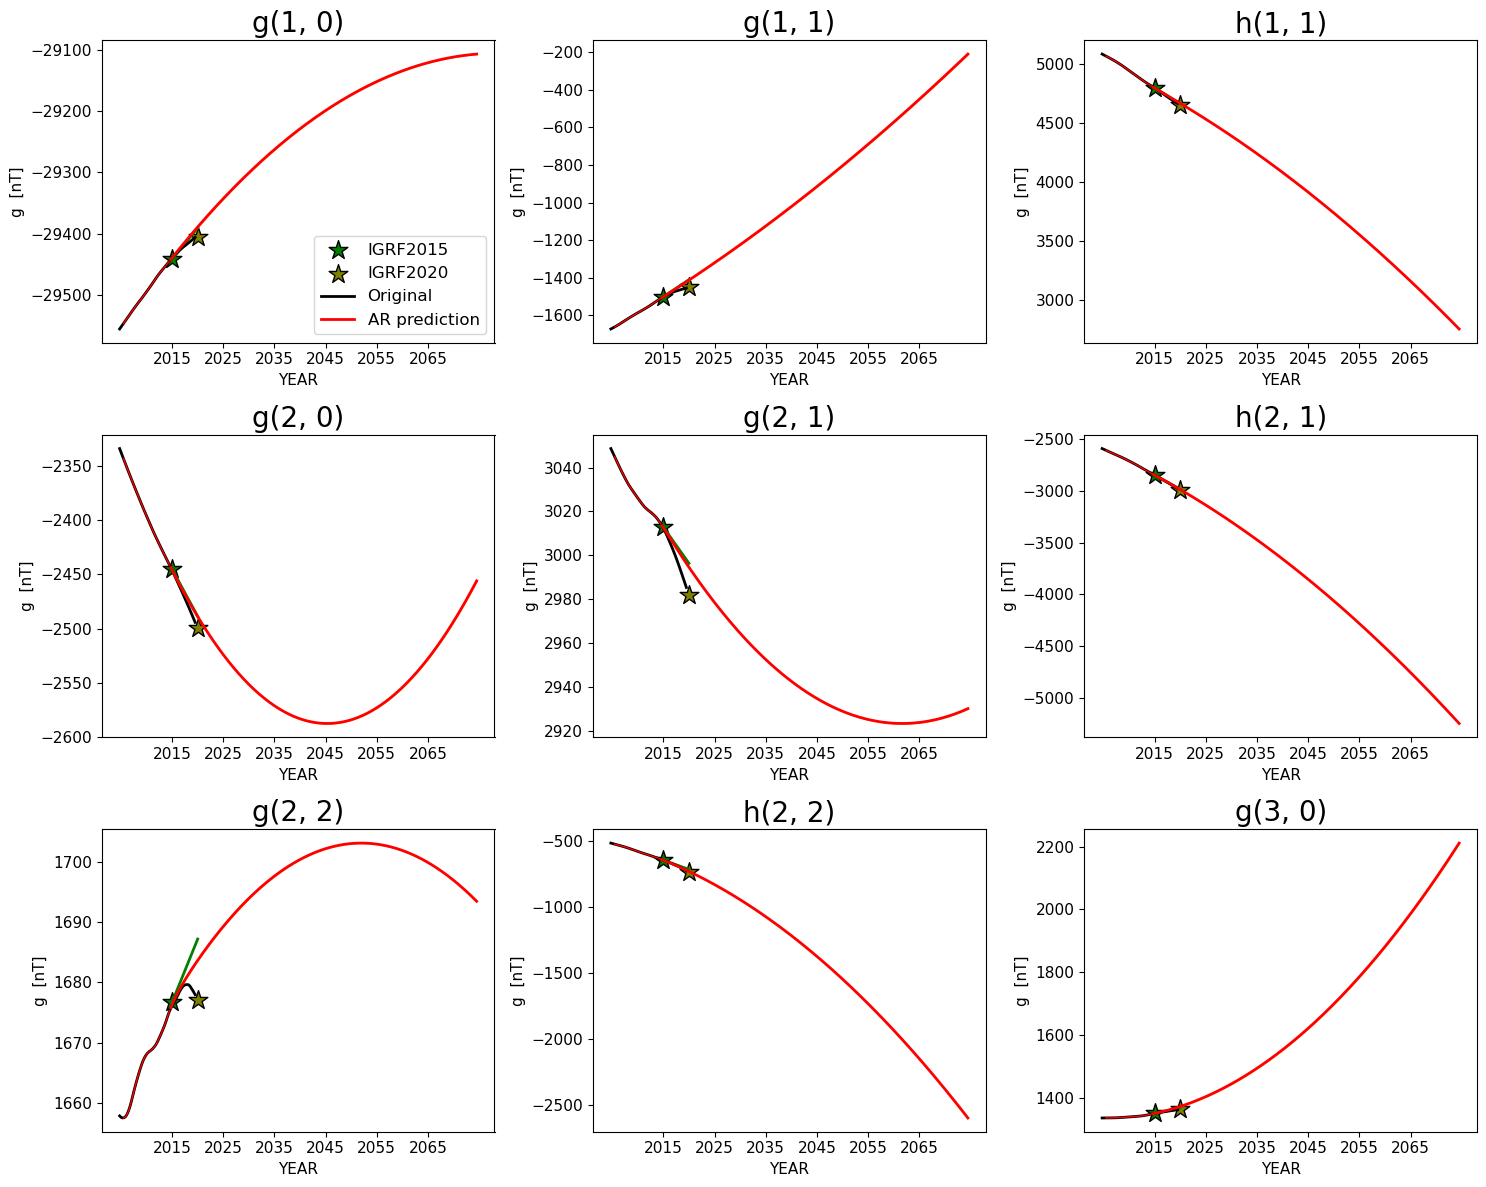

In [27]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    
    plot_result(ax, idx, target)
    ax.set_title(target, fontsize=20)
    ax.set_xticks(ex_test[1::40])

axes[0].legend(loc='lower right', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + "magpred_extend" + outtype)
plt.show()


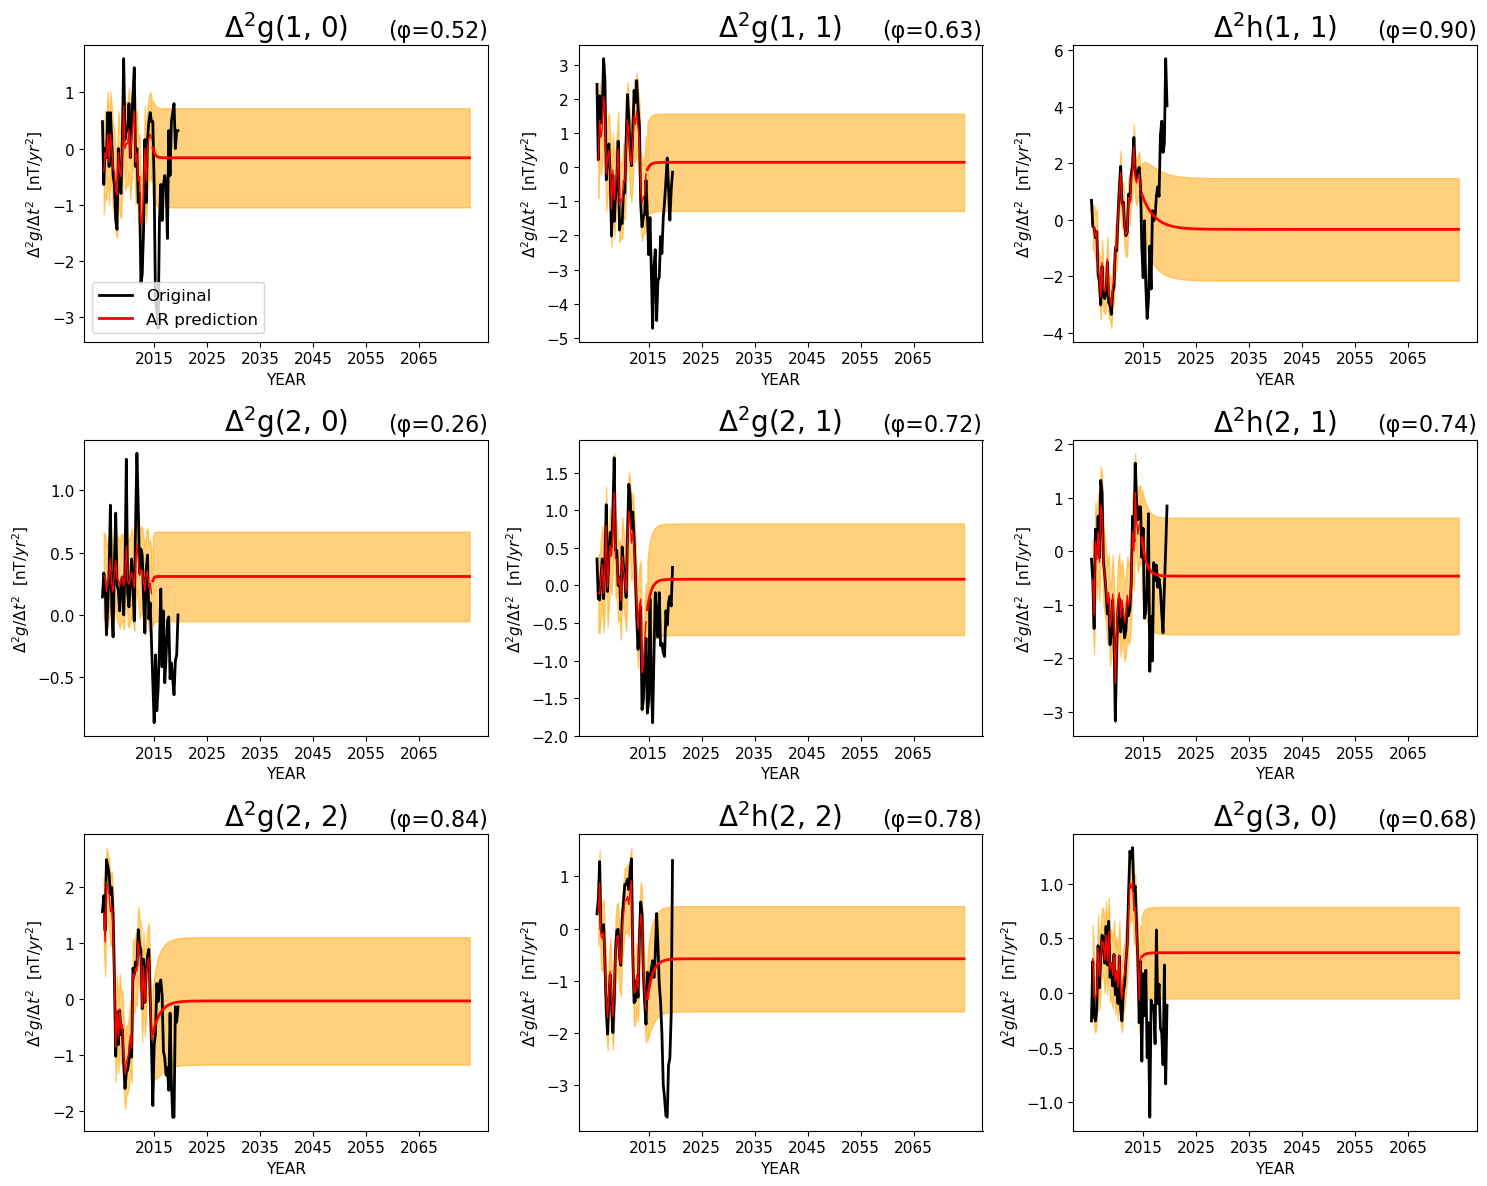

In [28]:
fig = plt.figure(figsize=(15,12))

fig.subplots_adjust(wspace=0.3, hspace=0.3)

figlocs = [331, 332, 333, 334, 335, 336, 337, 338, 339]
axes = [plt.subplot(figloc) for figloc in figlocs]
coef_idx = [1, 2, 3, 4, 5, 6, 7, 8, 9]

d2gdt_train = d2g_train * 4**2
d2gdt_test = d2g_test * 4**2
d2cdt_train = d2c_train * 4**2
d2cdt_test = d2c_test * 4**2

for i, ax in enumerate(axes):
    idx = coef_idx[i]
    target = coef_df.columns[idx-1]
    
    plot_dg(ax, 2, d2gdt_train, d2gdt_test, target)
    ax.fill_between(d2gdt_train.index, d2gdt_train[target]-d2cdt_train[target], d2gdt_train[target]+d2cdt_train[target], color='orange', alpha=0.5)
    ax.fill_between(d2gdt_test.index, d2gdt_test[target]-d2cdt_test[target], d2gdt_test[target]+d2cdt_test[target], color='orange', alpha=0.5) # 1 sigma ~= 68.3%

    ax.set_title(r"$\Delta^2$" + target, fontsize=20)
    ax.set_title(f"(φ={weights_df.loc['L1', target]:.2f})", loc="right", fontsize=16)
    
    ax.set_xticks(ex_test[1::40])


axes[0].legend(loc='lower left', fontsize=12)

plt.tight_layout()
plt.savefig(savedir + "magpred_d2g_extend" + outtype)
plt.show()


仮説通り、~~二次関数で fitting していることになる！~~
十分時間が経つと予測の期待値は二次関数に収束する。これはあくまで長期的な収束値であって、「短期SV予測が二次関数である」わけではない。

正しくは『release point の 2014.75時点を起点として、ガウス係数の3階時間微分が $\ddot{g}_t \approx c (1 + \phi_1 + \phi_1^2 + \cdots + \phi_1^{~t-1}) + \phi_1^{~t} \ddot{g}_{2014.75}$ で~~発展~~ const へ収束すると仮定している』。